# Hypothyroid Detection=

## Workflow
0. Optional environment setup
1. Data import and problem outline
2. Explore the data, with the train/validation/test split done before EDA
3. Feature engineering and preprocessing
4. Model selection and baseline exploration
5. Fine tuning, evaluation plots, and diagnostics
6. Final model choice, limitations, risks, and next steps


## 0. Optional Environment Setup

**What this chunk does**

The next cells install the notebook dependencies, import the project libraries, and define the dataframe styling helper used throughout the outputs.
None of this changes the modelling logic; it just recreates the original working notebook environment.


In [199]:
!pip install plotly
!pip install xgboost
!pip install shap
!pip install lightgbm
!pip install nbformat
!pip install missingno


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\qasim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\qasim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\qasim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\qasim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\qasim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\qasim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [200]:
# Core libraries to be used
import joblib
import os
import json
import random
import hashlib
import warnings
import xgboost as xgb
import lightgbm as lgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from datetime import datetime
from pathlib import Path
from typing import Any
from IPython.display import HTML
from IPython.display import display, Markdown
from pandas.api.types import CategoricalDtype
from pandas.api.types import is_categorical_dtype

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay)


warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)

In [201]:
#custom styles for tables

def style1(df):
    return df.style.set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("background-color", "#9ecae1"),
                ("color", "black"),
                ("border", "1px solid white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th.row_heading",
            "props": [
                ("text-align", "center")
            ]
        },
        {
            "selector": "th.blank",
            "props": [
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])

def style2(df):
    return df.style.set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("background-color", "#9ecae1"),
                ("color", "black"),
                ("border", "1px solid white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th.row_heading",
            "props": [
                ("text-align", "left")
            ]
        },
        {
            "selector": "th.blank",
            "props": [
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "left")
            ]
        }
    ])

## 1. Obtaining a Dataset and Framing the Predictive Problem

**Problem framing**

This project investigates the Hypothyroid Disease dataset from the UCI ML Repository (Quinlan, 1986). Hypothyroidism occurs when the thyroid produces too little hormone, slowing metabolism and causing fatigue, weight gain, and cold intolerance. Diagnosis typically relies on blood tests such as TSH and T4. Machine learning can predict risk from clinical features and lab results, supporting earlier detection and reducing missed or delayed diagnoses.

Clinical diagnoses, such as hypothyroidism, are a binary classification prediction problem where the target variable is the outcome, highlighted by the first column in hypothyroid.csv, where the values are either 'hypothyroidism' for true and 'negative' for false.


**Assumptions**
- Dataset from 1986 - similar diagnosis practices are still followed ~40 years later.
- Diagnosis (target) value is a direct result of the medical test data.
- Missing data is clinically driven (not fully random), which can bias learning.

**Limitations**
- The dataset is older and may not account for modern environmental factors.
- The dataset doesn’t include ethnicities, which may be important as different genetic backgrounds may have differing risk rates.
- Severe class imbalance (~3% hypothyroid) can inflate headline metrics.




### Data Import

**What this chunk does**

These cells read the raw CSV, assign the original variable names, preview the first few rows, and run a first-pass sanity check on duplicates, missing-value tokens, and class balance.


In [202]:
# Load the CSV file of the Hypothyroid Disease dataset
df_raw = pd.read_csv('hypothyroid.csv', header=None)


In [203]:
# Assigning descriptive column names
columns = [
    'Class', 'age', 'sex',
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
    'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid',
    'pregnant', 'sick', 'tumor', 'lithium', 'goitre',
    'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4',
    'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured', 'TBG'
]
df_raw.columns = columns

In [204]:
# Preview the raw dataset after assigning column names
style1(df_raw.head(6))


,Class,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,sick,tumor,lithium,goitre,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72,M,f,f,f,f,f,f,f,f,f,f,f,y,30,y,0.6,y,15,y,1.48,y,10,n,?
1,hypothyroid,15,F,t,f,f,f,f,f,f,f,f,f,f,y,145,y,1.7,y,19,y,1.13,y,17,n,?
2,hypothyroid,24,M,f,f,f,f,f,f,f,f,f,f,f,y,0,y,0.2,y,4,y,1,y,0,n,?
3,hypothyroid,24,F,f,f,f,f,f,f,f,f,f,f,f,y,430,y,0.4,y,6,y,1.04,y,6,n,?
4,hypothyroid,77,M,f,f,f,f,f,f,f,f,f,f,f,y,7.3,y,1.2,y,57,y,1.28,y,44,n,?
5,hypothyroid,85,F,f,f,f,f,t,f,f,f,f,f,f,y,138,y,1.1,y,27,y,1.19,y,23,n,?


In [205]:
# Brief post-import sanity check
print("Post-import sanity check")
print(f"Rows x columns: {df_raw.shape[0]} x {df_raw.shape[1]}")
print(f"Duplicate rows: {int(df_raw.duplicated().sum())}")
print(f"Cells containing '?': {int((df_raw == '?').sum().sum())}")
display(df_raw["Class"].value_counts(dropna=False).rename_axis("Class").to_frame("count"))


Post-import sanity check
Rows x columns: 3163 x 26
Duplicate rows: 77
Cells containing '?': 5329


,count
Class,
negative,3012
hypothyroid,151


**Output analysis**

The raw file contains **3,163 rows** and **26 columns** before canonical cleaning, with one target variable, there are 25 predictive variables.
The first sanity check also identifies early leakage risks and data quality issues: **77 duplicate rows**, **5,329 raw `"?"` tokens**, and a strongly imbalanced target with **3,012 negative** cases versus **151 hypothyroid** cases.

That combination justifies the next stage: standardise the raw representation, resolve duplicate leakage risk, and split the data before any exploratory analysis.


## 1b. Explore the Data Safely: Split Before EDA

Before any EDA is conducted, the agentic tool Codex built a pipeline consisting of a reproducible preprocessing-and-splitting scaffold. This is followed by the split into training/validation/test sets where then EDA is performed only on the training partition. That keeps the descriptive work aligned with the same leak-safe discipline used later in modelling.


### Reproducible Cleaning, Validation, and Split Utilities

**What this chunk does**

This large helper cell defines the canonicalisation rules, validation checks, duplicate handling, deterministic split logic, artifact writing, and leakage reporting used by the rest of the notebook.



From an agentic tooling perspective,  we delegated the majority of the pipeline planning and implementation to Codex as it was much more efficient in the production and structuring of functions for a pipeline scaffold as well as possessing the expertise on how to produce artifacts to enable reproducibility. This enabled verification of the Codex generated pipeline through both validation and reproducibility.

The preprocessing and split pipeline is designed to make the hypothyroid dataset reproducible, leakage-resistant, and model-ready. It first canonicalises the raw data by converting placeholder missing tokens such as ‘?’ values into standard nulls, coercing hormone and age fields to numeric types, lowercasing categorical values, and attaching a row ID so records can be tracked across stages. The cleaned data is then validated for schema consistency, class labels, missingness, implausible values, and measured-value mismatches before duplicate rows are resolved by removing conflicting feature signatures and retaining only one copy. After this, the dataset is stratified into 70% training, 15% validation, and 15% test splits so class prevalence is preserved with quality checks confirming no duplicate feature signatures across splits.

From that point onward, all learnable preprocessing is fit on the training split only: TBG is dropped because it is overwhelmingly sparse, percentile-based clipping thresholds are estimated for key hormone variables and then applied consistently to all splits, and engineered features are added to capture age missingness, overall hormone missingness, and how many hormone tests were actually measured. Finally, the model pipeline imputes numeric variables such as TSH, T3, TT4, T4U, and FTI with the training-set median, imputes categorical variables with the most frequent category, ordinal-encodes the binary clinical indicators, and applies the exact same fitted transformations to validation and test data, producing modelling-ready inputs without contaminating evaluation


In [206]:
#Codex generated pipeline for a Reproducible split + validation configuration and utilities


def set_reproducibility(cfg: dict) -> None:
    seed = int(cfg["seed"])
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

cfg = {
    "seed": 42,
    "split": (0.70, 0.15, 0.15),
    "target_col": "Class",
    "id_col": "__row_id__",
    "missing_tokens": ["?", "na", "Na", "NA", "None", "nan", "", " "],
    "drop_cols": ["TBG"],
    "artifact_dir": "artifacts/pipeline_v1",
    "dataset_path": "hypothyroid.csv",
    "numeric_cols": ["age", "TSH", "T3", "TT4", "T4U", "FTI", "TBG"],
    "clip_cols": ["TSH", "T3", "TT4", "T4U", "FTI"]
}
set_reproducibility(cfg)
print(f"Configured reproducible pipeline with seed={cfg['seed']}")

EXPECTED_COLUMNS = list(columns) if "columns" in globals() else [
    "Class", "age", "sex",
    "on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication",
    "thyroid_surgery", "query_hypothyroid", "query_hyperthyroid",
    "pregnant", "sick", "tumor", "lithium", "goitre",
    "TSH_measured", "TSH", "T3_measured", "T3", "TT4_measured", "TT4",
    "T4U_measured", "T4U", "FTI_measured", "FTI", "TBG_measured", "TBG"
]

def dataset_sha256(path: str) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def _json_default(obj: Any) -> Any:
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (pd.Timestamp, datetime)):
        return obj.isoformat()
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="records")
    if isinstance(obj, (set, tuple)):
        return list(obj)
    raise TypeError(f"Type not serializable: {type(obj)}")


def _normalise_missing_tokens(values: pd.Series, missing_tokens: list[str]) -> pd.Series:
    s = values.astype("string").str.strip()
    tokens = {t.lower() for t in missing_tokens}
    s_lower = s.str.lower()
    s = s.mask(s_lower.isin(tokens), pd.NA)
    return s


def _feature_signature(df: pd.DataFrame, feature_cols: list[str]) -> pd.Series:
    return (
        df[feature_cols]
        .astype("string")
        .fillna("__NA__")
        .agg("||".join, axis=1)
    )


def canonicalize(df_raw: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    df = df_raw.copy(deep=True)
    id_col = cfg["id_col"]
    target_col = cfg["target_col"]

    df[id_col] = df.index.astype(int)

    for col in EXPECTED_COLUMNS:
        if col not in df.columns:
            continue
        if col in cfg["numeric_cols"]:
            df[col] = _normalise_missing_tokens(df[col], cfg["missing_tokens"])
            df[col] = pd.to_numeric(df[col], errors="coerce")
        else:
            cleaned = _normalise_missing_tokens(df[col], cfg["missing_tokens"])
            df[col] = cleaned.str.lower()

    df[target_col] = df[target_col].where(df[target_col].isin(["negative", "hypothyroid"]), pd.NA)
    return df


def validate_raw(df: pd.DataFrame, cfg: dict) -> dict:
    id_col = cfg["id_col"]
    target_col = cfg["target_col"]

    errors = []
    warnings = []
    metrics = {}

    actual_cols = [c for c in df.columns if c != id_col]
    if actual_cols != EXPECTED_COLUMNS:
        errors.append("Schema mismatch: dataframe columns do not match expected order/content.")

    observed_classes = sorted(df[target_col].dropna().unique().tolist())
    expected_classes = ["hypothyroid", "negative"]
    if sorted(observed_classes) != sorted(expected_classes):
        errors.append(f"Target class mismatch. Observed={observed_classes}, expected={expected_classes}")

    missingness_pct = (df[EXPECTED_COLUMNS].isna().mean() * 100).sort_values(ascending=False)
    metrics["missingness_pct"] = {k: float(v) for k, v in missingness_pct.items()}

    numeric_cols_present = [c for c in cfg["numeric_cols"] if c in df.columns]
    negative_counts = {
        c: int((pd.to_numeric(df[c], errors="coerce") < 0).sum())
        for c in numeric_cols_present
    }
    metrics["negative_value_counts"] = negative_counts
    for col, n_bad in negative_counts.items():
        if n_bad > 0:
            warnings.append(f"{col}: found {n_bad} values below zero.")

    if "age" in df.columns:
        age_series = pd.to_numeric(df["age"], errors="coerce")
        age_oob = int(((age_series < 0) | (age_series > 120)).sum())
        metrics["age_out_of_bounds"] = age_oob
        if age_oob > 0:
            warnings.append(f"age: found {age_oob} values outside [0, 120].")

    measured_pairs = [
        ("TSH_measured", "TSH"),
        ("T3_measured", "T3"),
        ("TT4_measured", "TT4"),
        ("T4U_measured", "T4U"),
        ("FTI_measured", "FTI"),
        ("TBG_measured", "TBG")
    ]
    consistency = {}
    for flag_col, value_col in measured_pairs:
        if flag_col not in df.columns or value_col not in df.columns:
            continue
        flag = df[flag_col].astype("string").str.strip().str.lower()
        value = df[value_col]
        n_flag_n_value_present = int(((flag == "n") & value.notna()).sum())
        n_flag_y_value_missing = int(((flag == "y") & value.isna()).sum())
        consistency[f"{flag_col}->{value_col}"] = {
            "flag_n_but_value_present": n_flag_n_value_present,
            "flag_y_but_value_missing": n_flag_y_value_missing
        }
        if n_flag_n_value_present > 0:
            warnings.append(
                f"{flag_col}/{value_col}: {n_flag_n_value_present} rows have flag='n' but value present."
            )
    metrics["measured_value_consistency"] = consistency

    feature_cols = [c for c in EXPECTED_COLUMNS if c != target_col]
    signatures = _feature_signature(df, feature_cols)
    exact_duplicates = int(df[EXPECTED_COLUMNS].duplicated().sum())
    feature_duplicates = int(signatures.duplicated().sum())
    label_conflicts = int(df.assign(_sig=signatures).groupby("_sig", dropna=False)[target_col].nunique().gt(1).sum())

    metrics["duplicate_stats"] = {
        "exact_duplicates": exact_duplicates,
        "feature_duplicates": feature_duplicates,
        "label_conflict_groups": label_conflicts
    }

    metrics["row_count"] = int(len(df))
    class_counts = df[target_col].value_counts(dropna=False)
    metrics["class_counts"] = {str(k): int(v) for k, v in class_counts.items()}

    return {
        "passed": len(errors) == 0,
        "errors": errors,
        "warnings": warnings,
        "metrics": metrics
    }


def resolve_duplicates(df: pd.DataFrame, cfg: dict) -> tuple[pd.DataFrame, dict]:
    target_col = cfg["target_col"]
    id_col = cfg["id_col"]
    feature_cols = [c for c in EXPECTED_COLUMNS if c != target_col]

    work = df.copy()
    work["_sig"] = _feature_signature(work, feature_cols)

    sig_label_nunique = work.groupby("_sig", dropna=False)[target_col].nunique()
    conflict_sigs = set(sig_label_nunique[sig_label_nunique > 1].index)

    before_rows = int(len(work))
    conflict_rows_removed = int(work["_sig"].isin(conflict_sigs).sum())
    work = work.loc[~work["_sig"].isin(conflict_sigs)].copy()

    work = work.sort_values(id_col).drop_duplicates(subset="_sig", keep="first")
    after_rows = int(len(work))

    dedup_rows_removed = before_rows - conflict_rows_removed - after_rows

    report = {
        "rows_before": before_rows,
        "conflict_groups": int(len(conflict_sigs)),
        "conflict_rows_removed": conflict_rows_removed,
        "feature_duplicate_rows_removed": int(dedup_rows_removed),
        "rows_after": after_rows
    }

    work = work.drop(columns=["_sig"]).reset_index(drop=True)
    return work, report


def stratified_split(df: pd.DataFrame, cfg: dict) -> dict[str, pd.Index]:
    train_ratio, val_ratio, test_ratio = cfg["split"]
    seed = int(cfg["seed"])
    id_col = cfg["id_col"]
    target_col = cfg["target_col"]

    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("Split ratios must sum to 1.0")

    y = (df[target_col] == "hypothyroid").astype(int)
    idx_all = df.index

    idx_train_val, idx_test = train_test_split(
        idx_all,
        test_size=test_ratio,
        random_state=seed,
        stratify=y
    )

    y_train_val = y.loc[idx_train_val]
    val_relative = val_ratio / (train_ratio + val_ratio)

    idx_train, idx_val = train_test_split(
        idx_train_val,
        test_size=val_relative,
        random_state=seed,
        stratify=y_train_val
    )

    return {
        "train": pd.Index(df.loc[idx_train, id_col].astype(int).tolist(), name=id_col),
        "val": pd.Index(df.loc[idx_val, id_col].astype(int).tolist(), name=id_col),
        "test": pd.Index(df.loc[idx_test, id_col].astype(int).tolist(), name=id_col)
    }


def materialize_split(df: pd.DataFrame, ids: pd.Index, id_col: str) -> pd.DataFrame:
    return (
        df[df[id_col].isin(ids)]
        .copy()
        .sort_values(id_col)
        .reset_index(drop=True)
    )


def split_quality_checks(
    df: pd.DataFrame,
    split_ids: dict[str, pd.Index],
    cfg: dict,
    prevalence_tolerance_pp: float = 1.0
) -> dict:
    id_col = cfg["id_col"]
    target_col = cfg["target_col"]

    train_set = set(split_ids["train"].tolist())
    val_set = set(split_ids["val"].tolist())
    test_set = set(split_ids["test"].tolist())

    overlap_train_val = len(train_set & val_set)
    overlap_train_test = len(train_set & test_set)
    overlap_val_test = len(val_set & test_set)

    all_ids = set(df[id_col].tolist())
    union_ids = train_set | val_set | test_set
    coverage_ok = all_ids == union_ids

    full_prev = float((df[target_col] == "hypothyroid").mean())

    prevalence = {}
    prevalence_diff_pp = {}
    for split_name, ids in split_ids.items():
        sdf = materialize_split(df, ids, id_col)
        p = float((sdf[target_col] == "hypothyroid").mean())
        prevalence[split_name] = p
        prevalence_diff_pp[split_name] = abs(p - full_prev) * 100

    feature_cols = [c for c in EXPECTED_COLUMNS if c != target_col]
    signatures = {}
    for split_name, ids in split_ids.items():
        sdf = materialize_split(df, ids, id_col)
        signatures[split_name] = set(_feature_signature(sdf, feature_cols).tolist())

    signature_overlap = {
        "train_val": len(signatures["train"] & signatures["val"]),
        "train_test": len(signatures["train"] & signatures["test"]),
        "val_test": len(signatures["val"] & signatures["test"])
    }

    passed = all([
        overlap_train_val == 0,
        overlap_train_test == 0,
        overlap_val_test == 0,
        coverage_ok,
        all(v <= prevalence_tolerance_pp for v in prevalence_diff_pp.values()),
        all(v == 0 for v in signature_overlap.values())
    ])

    return {
        "passed": passed,
        "id_overlap": {
            "train_val": overlap_train_val,
            "train_test": overlap_train_test,
            "val_test": overlap_val_test
        },
        "coverage_ok": coverage_ok,
        "prevalence": prevalence,
        "prevalence_diff_pp": prevalence_diff_pp,
        "signature_overlap": signature_overlap,
        "sizes": {k: int(len(v)) for k, v in split_ids.items()}
    }

def leakage_audit(split_dfs: dict[str, pd.DataFrame], cfg: dict) -> dict:
    target_col = cfg["target_col"]
    risk_cols = [
        "query_hypothyroid", "query_hyperthyroid",
        "TSH_measured", "T3_measured", "TT4_measured",
        "T4U_measured", "FTI_measured", "TBG_measured"
    ]

    rows = []
    for split_name, sdf in split_dfs.items():
        y = (sdf[target_col] == "hypothyroid").astype(int)
        base_rate = float(y.mean())

        for col in risk_cols:
            if col not in sdf.columns:
                continue

            values = (
                sdf[col]
                .astype("string")
                .fillna("missing")
                .str.strip()
                .str.lower()
            )

            stats = (
                pd.DataFrame({"value": values, "y": y})
                .groupby("value", as_index=False)
                .agg(pos_rate=("y", "mean"), n=("y", "size"))
            )
            if stats.empty:
                continue

            stats["abs_gap_pp"] = (stats["pos_rate"] - base_rate).abs() * 100
            worst = stats.loc[stats["abs_gap_pp"].idxmax()]
            deterministic = bool(((stats["pos_rate"].isin([0.0, 1.0])) & (stats["n"] >= 20)).any())

            rows.append({
                "split": split_name,
                "feature": col,
                "baseline_rate": base_rate,
                "max_abs_gap_pp": float(worst["abs_gap_pp"]),
                "worst_value": str(worst["value"]),
                "worst_value_n": int(worst["n"]),
                "deterministic_flag": deterministic
            })

    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        ranked_df = pd.DataFrame(columns=["feature", "max_abs_gap_pp", "mean_abs_gap_pp", "any_deterministic"])
    else:
        ranked_df = (
            summary_df
            .groupby("feature", as_index=False)
            .agg(
                max_abs_gap_pp=("max_abs_gap_pp", "max"),
                mean_abs_gap_pp=("max_abs_gap_pp", "mean"),
                any_deterministic=("deterministic_flag", "max")
            )
            .sort_values(["max_abs_gap_pp", "mean_abs_gap_pp"], ascending=False)
            .reset_index(drop=True)
        )

    return {
        "split_feature_summary": summary_df.to_dict(orient="records"),
        "ranked_features": ranked_df.to_dict(orient="records")
    }


def write_manifest_and_indices(
    df: pd.DataFrame,
    split_ids: dict[str, pd.Index],
    reports: dict[str, dict],
    cfg: dict
) -> dict:
    artifact_dir = Path(cfg["artifact_dir"])
    artifact_dir.mkdir(parents=True, exist_ok=True)

    id_col = cfg["id_col"]
    target_col = cfg["target_col"]

    for split_name, ids in split_ids.items():
        out_path = artifact_dir / f"{split_name}_ids.csv"
        pd.DataFrame({id_col: pd.Index(ids).astype(int)}).to_csv(out_path, index=False)

    for report_name, report_obj in reports.items():
        out_path = artifact_dir / f"{report_name}.json"
        out_path.write_text(json.dumps(report_obj, indent=2, default=_json_default), encoding="utf-8")

    manifest = {
        "created_utc": datetime.utcnow().isoformat() + "Z",
        "dataset_path": cfg["dataset_path"],
        "dataset_sha256": dataset_sha256(cfg["dataset_path"]),
        "seed": int(cfg["seed"]),
        "split": list(cfg["split"]),
        "target_col": target_col,
        "id_col": id_col,
        "drop_cols": list(cfg["drop_cols"]),
        "missing_tokens": list(cfg["missing_tokens"]),
        "row_count": int(len(df)),
        "class_counts": {
            str(k): int(v)
            for k, v in df[target_col].value_counts(dropna=False).to_dict().items()
        },
        "split_sizes": {k: int(len(v)) for k, v in split_ids.items()},
        "reports_written": [f"{name}.json" for name in reports.keys()],
        "id_files": [f"{name}_ids.csv" for name in split_ids.keys()]
    }

    manifest_path = artifact_dir / "manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2, default=_json_default), encoding="utf-8")
    return manifest


def update_manifest(extra_fields: dict, cfg: dict) -> dict:
    manifest_path = Path(cfg["artifact_dir"]) / "manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    else:
        manifest = {}

    manifest.update(extra_fields)
    manifest["updated_utc"] = datetime.utcnow().isoformat() + "Z"

    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    manifest_path.write_text(json.dumps(manifest, indent=2, default=_json_default), encoding="utf-8")
    return manifest


Configured reproducible pipeline with seed=42


**Pre-processing**

Importantly, the 5329 cells containing '?' are converted to recognisable missing value types (pd.NA & NaN) so that they can be recognsied by python functions when it comes to the EDA and data processing.

**Reproducibility**
Artefacts have been planned and created by Codex to ensure reproducibility of this ML project as the ability to trace and audit data points and changes made across runs.

- train_ids.csv: Exact row IDs assigned to train. Reuse to recreate the same training split.
- val_ids.csv: Exact validation IDs. Use to verify split stability.
- test_ids.csv: Exact test IDs. Ensures the same holdout set each run.
- split_report.json: Split QC (overlap, coverage, prevalence drift, signature overlap). Validate leakage-safe splitting.
- validation_report.json: Data validation metrics and pass/fail checks. Confirm raw-to-canonical quality is consistent.
- duplicate_resolution_report.json: Counts of conflicts/duplicates removed. Verify cleaning decisions are repeatable.
- leakage_report.json: Leakage-risk feature diagnostics. Check that risk profile stays stable across reruns.
- model_input_summary.json: Final transformed shapes, feature count, class-weight stats. Validate model-ready inputs are identical.
- preprocessor.joblib: Serialized fitted preprocessor. Reuse to transform new data exactly the same way.
- manifest.json: Run metadata (dataset hash, seed, split config, reports written). Primary file to confirm full-run reproducibility.




###  Canonicalise the Raw Dataset and Resolve Duplication

**What this chunk does**

These cells standardise the raw dataframe, validate the cleaned representation, mitigate leakage risks by remove duplicate feature signatures, and keep a short audit trail of what changed.


In [207]:
# Canonicalize data for reproducible downstream processing
df_can = canonicalize(df_raw, cfg)

print("Canonical dataframe shape:", df_can.shape)
print("Canonical class counts:")
print(f"Duplicate rows: {int(df_can.duplicated().sum())}")
print(f"Cells containing '?': {int((df_can == '?').sum().sum())}")
print(df_can[cfg["target_col"]].value_counts(dropna=False).to_string())


Canonical dataframe shape: (3163, 27)
Canonical class counts:
Duplicate rows: 0
Cells containing '?': 0
Class
negative       3012
hypothyroid     151


This second sanity check reinforces the logic that the '?' values have been replaced with standardised values. It also confirms that the duplicate rows have been removed, mitigating that potential leakage risk across data splits.

In [208]:
# Validation checks on canonicalized data
validation_report_raw = validate_raw(df_can, cfg)

print("Validation passed:", validation_report_raw["passed"])
print("Errors:", validation_report_raw["errors"])
print(f"Warning count: {len(validation_report_raw['warnings'])}")
if validation_report_raw["warnings"]:
    print("Top warnings:")
    for w in validation_report_raw["warnings"][:8]:
        print("-", w)

missing_table = (
    pd.DataFrame(
        list(validation_report_raw["metrics"]["missingness_pct"].items()),
        columns=["feature", "missing_pct"]
    )
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)
style1(missing_table.head(12))


Validation passed: True
Errors: []
Warning count: 0


,feature,missing_pct
0,TBG,91.779956
1,T3,21.972811
2,TSH,14.796080
3,age,14.100537
4,TT4,7.872273
5,T4U,7.840658
6,FTI,7.809042
7,sex,2.307936
8,Class,0.000000
9,on_thyroxine,0.000000


This table briefly quantifies the distribution of missing datapoints across the variables, with TBG test results standing out as being a predominantly empty column which may influence data processing decisions later on.

In [209]:
# Resolve label conflicts and deduplicate feature-signature rows
df_model, duplicate_resolution_report = resolve_duplicates(df_can, cfg)

print("Duplicate resolution report:")
print(json.dumps(duplicate_resolution_report, indent=2, default=_json_default))
print("Rows before:", len(df_can), "| Rows after:", len(df_model))


Duplicate resolution report:
{
  "rows_before": 3163,
  "conflict_groups": 1,
  "conflict_rows_removed": 2,
  "feature_duplicate_rows_removed": 77,
  "rows_after": 3084
}
Rows before: 3163 | Rows after: 3084


**Output analysis**

Validation passes cleanly, which means the canonical dataset has the expected schema and missing-value handling.
After removing duplicates and conflict resolution, the working modelling table drops from **3,163** rows to **3,084** rows, with **1 conflicting feature-signature group** resolved and duplicate leakage risk removed before splitting.


### Train/Validate/Test Split

**What this chunk does**

The next cells create the **70/15/15** stratified split, verify split quality, materialise the split dataframes, persist artifacts to disk, and run a final overlap/prevalence sanity check.


In [210]:
# Deterministic 70/15/15 stratified split
split_ids = stratified_split(df_model, cfg)
train_ids = split_ids["train"]
val_ids = split_ids["val"]
test_ids = split_ids["test"]

print("Split sizes:", {k: len(v) for k, v in split_ids.items()})


Split sizes: {'train': 2158, 'val': 463, 'test': 463}


In [211]:
# Split QA checks: overlap, prevalence tolerance, cross-split signature overlap
split_report = split_quality_checks(df_model, split_ids, cfg, prevalence_tolerance_pp=1.0)
print(json.dumps(split_report, indent=2, default=_json_default))

if not split_report["passed"]:
    raise ValueError("Split QA checks failed. Inspect split_report before proceeding.")


{
  "passed": true,
  "id_overlap": {
    "train_val": 0,
    "train_test": 0,
    "val_test": 0
  },
  "coverage_ok": true,
  "prevalence": {
    "train": 0.04541241890639481,
    "val": 0.04535637149028078,
    "test": 0.04535637149028078
  },
  "prevalence_diff_pp": {
    "train": 0.0016828763722956386,
    "val": 0.003921865239107231,
    "test": 0.003921865239107231
  },
  "signature_overlap": {
    "train_val": 0,
    "train_test": 0,
    "val_test": 0
  },
  "sizes": {
    "train": 2158,
    "val": 463,
    "test": 463
  }
}


In [212]:
# Materialize split dataframes
df_train = materialize_split(df_model, train_ids, cfg["id_col"])
df_val = materialize_split(df_model, val_ids, cfg["id_col"])
df_test = materialize_split(df_model, test_ids, cfg["id_col"])

print("Materialized split shapes:")
for name, sdf in {"train": df_train, "val": df_val, "test": df_test}.items():
    print(f"- {name}: {sdf.shape}")


Materialized split shapes:
- train: (2158, 27)
- val: (463, 27)
- test: (463, 27)


In [213]:
# Freeze explicit split containers for downstream EDA and preprocessing
split_dfs_raw = {
    "train": df_train.copy(),
    "val": df_val.copy(),
    "test": df_test.copy(),
}

eda_train = split_dfs_raw["train"].copy()

print("Prepared split containers:")
for name, sdf in split_dfs_raw.items():
    print(f"- {name}: {sdf.shape}")
print("EDA source:", eda_train.shape)


Prepared split containers:
- train: (2158, 27)
- val: (463, 27)
- test: (463, 27)
EDA source: (2158, 27)


In [214]:
# Persist split ids + validation reports + base manifest
reports_stage1 = {
    "validation_report": validation_report_raw,
    "split_report": split_report,
    "duplicate_resolution_report": duplicate_resolution_report
}

manifest = write_manifest_and_indices(df_model, split_ids, reports_stage1, cfg)

print("Artifacts written to:", cfg["artifact_dir"])
print("Manifest summary:")
print(json.dumps({
    "dataset_sha256": manifest["dataset_sha256"],
    "row_count": manifest["row_count"],
    "split_sizes": manifest["split_sizes"]
}, indent=2))


Artifacts written to: artifacts/pipeline_v1
Manifest summary:
{
  "dataset_sha256": "9513c8975d0e1d365e203e9196c422a16b04a3d04db256566fd7fd36b05e31e8",
  "row_count": 3084,
  "split_sizes": {
    "train": 2158,
    "val": 463,
    "test": 463
  }
}


In [215]:
# Reproducibility smoke test: reload split ids and compare to in-memory ids
artifact_dir = Path(cfg["artifact_dir"])
id_col = cfg["id_col"]

split_ids_disk = {
    name: pd.read_csv(artifact_dir / f"{name}_ids.csv")[id_col].astype(int).tolist()
    for name in ["train", "val", "test"]
}

repro_check = True
for name in ["train", "val", "test"]:
    mem_ids = sorted(pd.Index(split_ids[name]).astype(int).tolist())
    disk_ids = sorted(split_ids_disk[name])
    if mem_ids != disk_ids:
        repro_check = False

assert repro_check, "Reproducibility smoke test failed: disk ids do not match in-memory ids."
print("repro_check=", repro_check)


repro_check= True


In [216]:
# Deferred leakage stage: report only (no feature dropping in this phase)
leakage_report = leakage_audit(split_dfs_raw, cfg)

artifact_dir = Path(cfg["artifact_dir"])
artifact_dir.mkdir(parents=True, exist_ok=True)
(artifact_dir / "leakage_report.json").write_text(
    json.dumps(leakage_report, indent=2, default=_json_default),
    encoding="utf-8"
)

print("Leakage report written:", str(artifact_dir / "leakage_report.json"))
if leakage_report["ranked_features"]:
    leakage_ranked_df = pd.DataFrame(leakage_report["ranked_features"])
    style1(leakage_ranked_df.head(10))
else:
    print("No leakage-risk features were found in the configured scan.")


Leakage report written: artifacts\pipeline_v1\leakage_report.json


In [217]:
# Brief post-split sanity check
assert sum(len(ids) for ids in split_ids.values()) == len(df_model)
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids).isdisjoint(test_ids)
assert set(val_ids).isdisjoint(test_ids)

split_preview = {
    name: materialize_split(df_model, ids, cfg["id_col"])
    for name, ids in split_ids.items()
}

print("Post-split sanity check")
display(style1(pd.Series({name: len(sdf) for name, sdf in split_preview.items()}, name="rows").to_frame()))
display(style1(
    pd.concat(
        {
            name: sdf[cfg["target_col"]].value_counts(normalize=True, dropna=False)
            for name, sdf in split_preview.items()
        },
        axis=1,
    ).fillna(0).round(4)
)
)


Post-split sanity check


,rows
train,2158
val,463
test,463


,train,val,test
Class,,,
negative,0.954600,0.954600,0.954600
hypothyroid,0.045400,0.045400,0.045400


The saved split is balanced in the right way: **2,158 train**, **463 validation**, and **463 test** rows, with zero overlap across split ids and zero cross-split feature-signature overlap.
Class prevalence stays effectively identical across all three partitions at about **4.54% hypothyroid**, so any later performance differences are far more likely to reflect model behaviour than split drift.


## 2. Explore the Data to Gain Insights (EDA)

Everything below uses the training partition as the EDA view.
That keeps the narrative readable without leaking held-out information into feature design or model choice.


#### 2.1 Missing Data

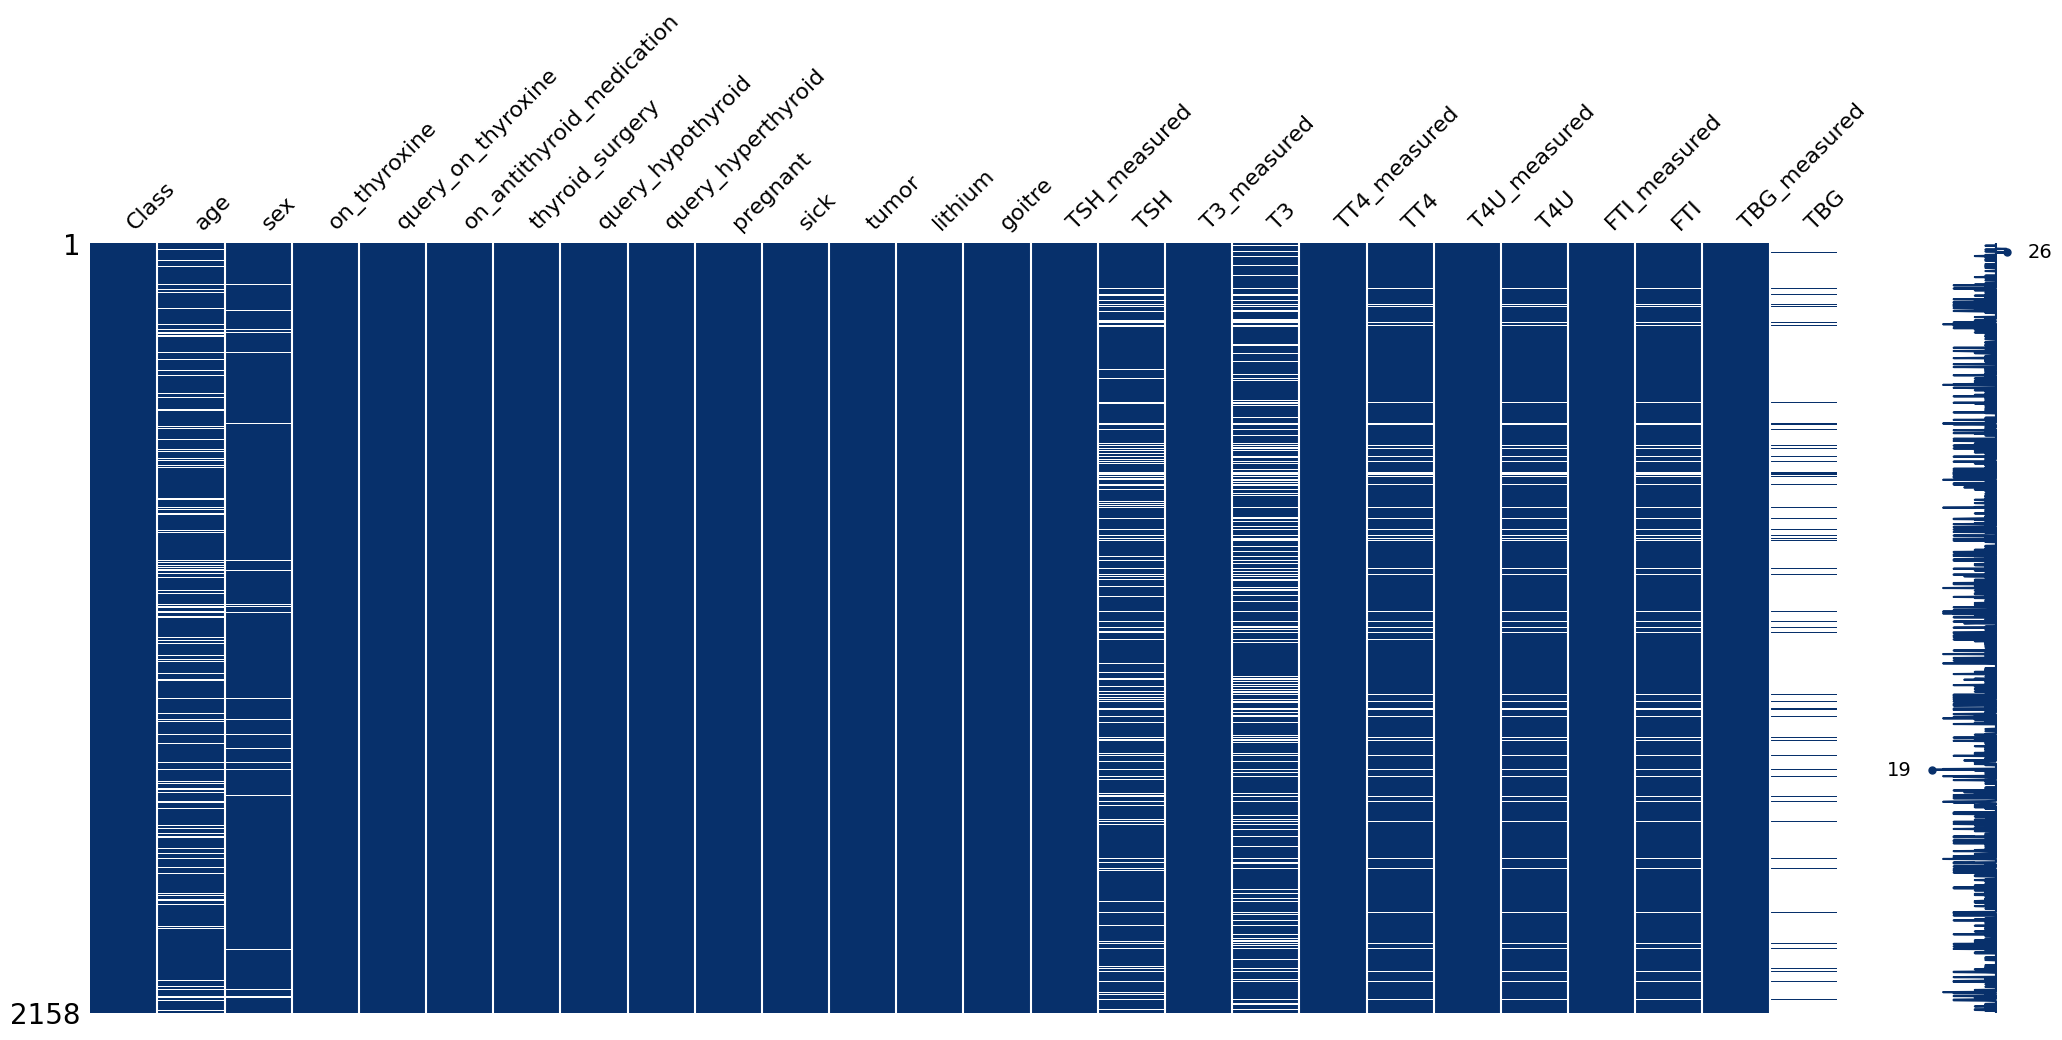

In [218]:
# Training-split missingness matrix before preprocessing
import missingno as msno

eda_missing = eda_train.drop(columns=[cfg["id_col"]], errors="ignore").copy()
msno.matrix(eda_missing, color=(0.03, 0.19, 0.42));


<p style="text-align:justify;"><b>Figure 1.</b> Missing data matrix showing the pattern and extent of missing values across all features, used to identify gaps before cleaning.</p>

Here, missing data is seen only in numerical variables, with the worst coming from TBG results. Only 174 out of 2158 TBG test results are present. However, certain hormone values are missing because certain lab tests were not performed, which reflects clinical decision making rather than random absence. This pattern aligns with Missing Not At Random (MNAR), since tests such as T3 or T4U are typically ordered only when thyroid dysfunction is suspected (Kang, 2013; Austin et al., 2021). In addition, the dataset was collected from diverse labs and each site may follow different protocols on test collection.

In [219]:
#quantifies the missingness in the TBG column for the training split
eda_tbg = eda_train.copy()
eda_tbg["TBG"] = pd.to_numeric(eda_tbg["TBG"], errors="coerce")

tbg_summary = pd.DataFrame({
    "Category": ["Valid TBG values", "Missing TBG values"],
    "Count": [
        eda_tbg["TBG"].notna().sum(),
        eda_tbg["TBG"].isna().sum()
    ]
})

style1(tbg_summary)


,Category,Count
0,Valid TBG values,174
1,Missing TBG values,1984


Missingness is clearly structured rather than random.
The `TBG` summary confirms that most rows do not contain a usable `TBG` value, so keeping the raw measurement as a core modelling feature would add sparsity with limited benefit.

That supports the later decision to drop raw `TBG` from the modelling feature set while still preserving related measured/not-measured information.


#### 2.2 Class Imbalance


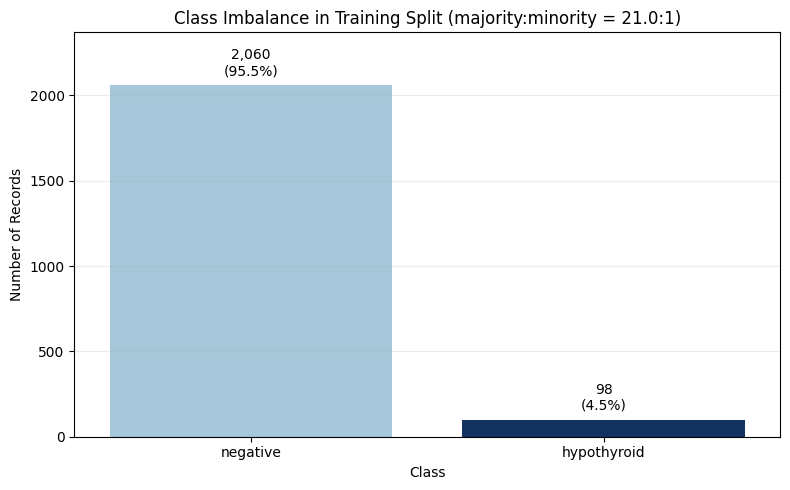

In [220]:
#Codex Generated Code - Experimenting to see how quickly and effectively it can generate EDA code for a simple class imbalance visualisation

# Class imbalance plot for the training split
class_counts = (
    eda_train['Class']
    .astype(str)
    .str.strip()
    .value_counts()
    .reindex(['negative', 'hypothyroid'], fill_value=0)
)

class_pct = class_counts / class_counts.sum() * 100
imbalance_ratio = np.inf if class_counts.min() == 0 else class_counts.max() / class_counts.min()

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette=['#9ecae1', '#08306b']
)

for i, (count, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    ax.text(
        i, count + class_counts.max() * 0.02,
        f"{count:,}\n({pct:.1f}%)",
        ha='center', va='bottom', fontsize=10
    )

plt.title(f"Class Imbalance in Training Split (majority:minority = {imbalance_ratio:.1f}:1)")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.ylim(0, class_counts.max() * 1.15)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


<p style="text-align:justify;"><b>Figure 2.</b> Highlights the class imbalance within the training split</p>

This visualisation revisits the previously mentioned class imbalance that exists in the dataset - highlighted again here in the training split. This extreme imbalance can bias models toward predicting the majority class (negative), producing deceptively high accuracy while missing true hypothyroid patients (low recall). It can also make metrics less stable due to the small number of positives, and requires careful evaluation (e.g., PR-AUC) and threshold/class-weight tuning.


#### 2.4.3 Hormone Distributions and Outlier Structure

**What this chunk does**

These cells inspect the continuous hormone features in the training split, compare their distributions by class, and highlight where IQR- and percentile-based outlier rules disagree.


In [221]:
#Codex generated code that aims to improve on previous boxplots by explicitly flagging outliers according to both IQR and percentile-based rules, and visualizing them with distinct symbols in a combined plot.

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Build a training-only EDA copy so later modelling objects remain untouched
eda_outlier_train = eda_train.copy()
eda_outlier_train.columns = eda_outlier_train.columns.str.strip()

if "Class" in eda_outlier_train.columns:
    eda_outlier_train["Class"] = (
        eda_outlier_train["Class"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

class_order = ["negative", "hypothyroid"]
eda_outlier_train = eda_outlier_train[eda_outlier_train["Class"].isin(class_order)].copy()
eda_outlier_train["Class"] = pd.Categorical(
    eda_outlier_train["Class"],
    categories=class_order,
    ordered=True
)

hormones = [col for col in cfg["clip_cols"] if col in eda_outlier_train.columns]
missing_map = {token: np.nan for token in cfg["missing_tokens"]}

for col in hormones:
    eda_outlier_train[col] = pd.to_numeric(
        eda_outlier_train[col].replace(missing_map),
        errors="coerce"
    )

id_vars = ["Class"]
if cfg["id_col"] in eda_outlier_train.columns:
    id_vars.append(cfg["id_col"])

outlier_points_long = (
    eda_outlier_train[id_vars + hormones]
    .melt(
        id_vars=id_vars,
        value_vars=hormones,
        var_name="Hormone",
        value_name="Value"
    )
    .dropna(subset=["Value"])
    .copy()
)

bounds_rows = []
for hormone in hormones:
    series = outlier_points_long.loc[outlier_points_long["Hormone"] == hormone, "Value"]
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))
    iqr = q3 - q1
    bounds_rows.extend([
        {
            "Hormone": hormone,
            "rule": "IQR",
            "rule_display": "1.5*IQR",
            "lower_bound": float(q1 - 1.5 * iqr),
            "upper_bound": float(q3 + 1.5 * iqr),
        },
        {
            "Hormone": hormone,
            "rule": "Percentile",
            "rule_display": "1st/99th percentile",
            "lower_bound": float(series.quantile(0.01)),
            "upper_bound": float(series.quantile(0.99)),
        },
    ])

outlier_bounds_df = pd.DataFrame(bounds_rows)

bounds_wide = (
    outlier_bounds_df
    .pivot(index="Hormone", columns="rule", values=["lower_bound", "upper_bound"])
)
bounds_wide.columns = [
    f"{rule.lower()}_{bound.split('_')[0]}"
    for bound, rule in bounds_wide.columns
]
bounds_wide = bounds_wide.reset_index()

outlier_points_long = outlier_points_long.merge(bounds_wide, on="Hormone", how="left")
outlier_points_long["flag_iqr"] = (
    (outlier_points_long["Value"] < outlier_points_long["iqr_lower"])
    | (outlier_points_long["Value"] > outlier_points_long["iqr_upper"])
)
outlier_points_long["flag_pct"] = (
    (outlier_points_long["Value"] < outlier_points_long["percentile_lower"])
    | (outlier_points_long["Value"] > outlier_points_long["percentile_upper"])
)
outlier_points_long["flag_any"] = outlier_points_long[["flag_iqr", "flag_pct"]].any(axis=1)
outlier_points_long["flag_label"] = np.select(
    [
        outlier_points_long["flag_iqr"] & outlier_points_long["flag_pct"],
        outlier_points_long["flag_iqr"],
        outlier_points_long["flag_pct"],
    ],
    ["Both", "IQR only", "Percentile only"],
    default="Not flagged"
)
outlier_points_long["rule_symbol"] = outlier_points_long["flag_label"].map(
    {
        "Percentile only": "circle",
        "IQR only": "diamond",
        "Both": "x",
        "Not flagged": "circle-open",
    }
)
outlier_points_long["Hormone"] = pd.Categorical(
    outlier_points_long["Hormone"],
    categories=hormones,
    ordered=True
)
outlier_points_long["Class"] = pd.Categorical(
    outlier_points_long["Class"],
    categories=class_order,
    ordered=True
)

summary_rows = []
for hormone in hormones:
    for cls in class_order:
        group = outlier_points_long[
            (outlier_points_long["Hormone"] == hormone)
            & (outlier_points_long["Class"] == cls)
        ].copy()
        n_non_missing = int(len(group))
        hormone_bounds = outlier_bounds_df[outlier_bounds_df["Hormone"] == hormone].set_index("rule")
        for rule, flag_col in [("IQR", "flag_iqr"), ("Percentile", "flag_pct")]:
            n_flagged = int(group[flag_col].sum())
            pct_flagged = float((n_flagged / n_non_missing) * 100) if n_non_missing else 0.0
            summary_rows.append(
                {
                    "Hormone": hormone,
                    "Class": cls,
                    "rule": rule,
                    "rule_display": hormone_bounds.loc[rule, "rule_display"],
                    "n_non_missing": n_non_missing,
                    "n_flagged": n_flagged,
                    "pct_flagged": pct_flagged,
                    "lower_bound": float(hormone_bounds.loc[rule, "lower_bound"]),
                    "upper_bound": float(hormone_bounds.loc[rule, "upper_bound"]),
                }
            )

outlier_summary_df = pd.DataFrame(summary_rows)
outlier_summary_df["Hormone"] = pd.Categorical(
    outlier_summary_df["Hormone"],
    categories=hormones,
    ordered=True
)
outlier_summary_df["Class"] = pd.Categorical(
    outlier_summary_df["Class"],
    categories=class_order,
    ordered=True
)
outlier_summary_df = outlier_summary_df.sort_values(["Hormone", "rule", "Class"]).reset_index(drop=True)

print("Prepared pre-clipping outlier EDA objects:")
print("- eda_outlier_train:", eda_outlier_train.shape)
print("- outlier_bounds_df:", outlier_bounds_df.shape)
print("- outlier_points_long:", outlier_points_long.shape)
print("- outlier_summary_df:", outlier_summary_df.shape)

Prepared pre-clipping outlier EDA objects:
- eda_outlier_train: (2158, 27)
- outlier_bounds_df: (10, 5)
- outlier_points_long: (9499, 13)
- outlier_summary_df: (20, 9)


In [222]:
#Codex generated code that aims to improve on previous boxplots by explicitly flagging outliers according to both IQR and percentile-based rules, and visualizing them with distinct symbols in a combined plot.

class_colors = {
    "negative": "#9ecae1",
    "hypothyroid": "#08306b",
}
fill_colors = {
    "negative": "rgba(158, 202, 225, 0.35)",
    "hypothyroid": "rgba(8, 48, 107, 0.30)",
}
rule_symbols = {
    "Percentile only": "circle",
    "IQR only": "diamond",
    "Both": "x",
}
summary_rule_symbols = {
    "IQR": "diamond",
    "Percentile": "circle",
}
summary_offsets = {
    ("negative", "IQR"): -0.18,
    ("hypothyroid", "IQR"): -0.06,
    ("negative", "Percentile"): 0.06,
    ("hypothyroid", "Percentile"): 0.18,
}

fig = make_subplots(
    rows=2,
    cols=len(hormones),
    row_heights=[0.72, 0.28],
    vertical_spacing=0.20,
    specs=[
        [{} for _ in hormones],
        [{"colspan": len(hormones)}] + [None] * (len(hormones) - 1),
    ],
    subplot_titles=hormones + ["Outlier burden by class and rule"],
)

for col_idx, hormone in enumerate(hormones, start=1):
    hormone_points = outlier_points_long[outlier_points_long["Hormone"] == hormone]

    for cls in class_order:
        cls_points = hormone_points[hormone_points["Class"] == cls]
        if cls_points.empty:
            continue

        fig.add_trace(
            go.Violin(
                x=cls_points["Class"].astype(str),
                y=cls_points["Value"],
                name=cls.title(),
                legendgroup=f"class_{cls}",
                scalegroup=hormone,
                line_color=class_colors[cls],
                fillcolor=fill_colors[cls],
                opacity=0.85,
                box_visible=True,
                meanline_visible=False,
                points=False,
                showlegend=(col_idx == 1),
                spanmode="hard",
            ),
            row=1,
            col=col_idx,
        )

    flagged_points = hormone_points[hormone_points["flag_any"]].copy()
    if cfg["id_col"] in flagged_points.columns:
        flagged_points[cfg["id_col"]] = flagged_points[cfg["id_col"]].astype(int).astype(str)
    else:
        flagged_points[cfg["id_col"]] = "NA"

    for flag_label in ["Percentile only", "IQR only", "Both"]:
        flagged_subset = flagged_points[flagged_points["flag_label"] == flag_label]
        if flagged_subset.empty:
            continue

        customdata = np.column_stack([
            flagged_subset["Hormone"].astype(str),
            flagged_subset["flag_label"],
            flagged_subset[cfg["id_col"]],
        ])

        fig.add_trace(
            go.Scatter(
                x=flagged_subset["Class"].astype(str),
                y=flagged_subset["Value"],
                mode="markers",
                marker=dict(
                    symbol=rule_symbols[flag_label],
                    size=8,
                    color=flagged_subset["Class"].astype(str).map(class_colors),
                    line=dict(color="#1f1f1f", width=0.8),
                    opacity=0.9,
                ),
                customdata=customdata,
                hovertemplate=(
                    "Hormone=%{customdata[0]}<br>"
                    "Class=%{x}<br>"
                    "Measured value=%{y:.2f}<br>"
                    "Flag=%{customdata[1]}<br>"
                    "Row ID=%{customdata[2]}<extra></extra>"
                ),
                showlegend=False,
                legendgroup=f"rule_{flag_label}",
                name=flag_label,
            ),
            row=1,
            col=col_idx,
        )

    fig.update_xaxes(
        categoryorder="array",
        categoryarray=class_order,
        showgrid=False,
        title_text="",
        row=1,
        col=col_idx,
    )
    fig.update_yaxes(
        showgrid=True,
        gridcolor="lightgrey",
        title_text="Measured value" if col_idx == 1 else "",
        row=1,
        col=col_idx,
    )

for flag_label, symbol in rule_symbols.items():
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode="markers",
            marker=dict(
                symbol=symbol,
                size=9,
                color="white",
                line=dict(color="#1f1f1f", width=1.1),
            ),
            name=flag_label,
            legendgroup=f"legend_{flag_label}",
            showlegend=True,
        ),
        row=1,
        col=1,
    )

hormone_positions = {hormone: idx for idx, hormone in enumerate(hormones)}
for cls in class_order:
    for rule in ["IQR", "Percentile"]:
        subset = outlier_summary_df[
            (outlier_summary_df["Class"] == cls)
            & (outlier_summary_df["rule"] == rule)
        ].sort_values("Hormone")
        if subset.empty:
            continue

        x_values = [
            hormone_positions[hormone] + summary_offsets[(cls, rule)]
            for hormone in subset["Hormone"].astype(str)
        ]
        customdata = np.column_stack([
            subset["Hormone"].astype(str),
            subset["Class"].astype(str),
            subset["rule_display"],
            subset["n_non_missing"].astype(int),
            subset["n_flagged"].astype(int),
            subset["pct_flagged"],
            subset["lower_bound"],
            subset["upper_bound"],
        ])

        fig.add_trace(
            go.Scatter(
                x=x_values,
                y=subset["pct_flagged"],
                mode="markers",
                marker=dict(
                    symbol=summary_rule_symbols[rule],
                    size=12,
                    color=class_colors[cls],
                    line=dict(color="#1f1f1f", width=1),
                ),
                customdata=customdata,
                hovertemplate=(
                    "Hormone=%{customdata[0]}<br>"
                    "Class=%{customdata[1]}<br>"
                    "Rule=%{customdata[2]}<br>"
                    "Flagged=%{customdata[4]} / %{customdata[3]}<br>"
                    "Percent=%{customdata[5]:.2f}%<br>"
                    "Bounds=[%{customdata[6]:.2f}, %{customdata[7]:.2f}]<extra></extra>"
                ),
                showlegend=False,
            ),
            row=2,
            col=1,
        )

fig.update_xaxes(
    row=2,
    col=1,
    tickmode="array",
    tickvals=list(hormone_positions.values()),
    ticktext=hormones,
    range=[-0.5, len(hormones) - 0.5],
    showgrid=False,
    title_text="Hormone",
)
fig.update_yaxes(
    row=2,
    col=1,
    showgrid=True,
    gridcolor="lightgrey",
    title_text="Percent flagged within class",
)

fig.update_layout(
    title_text="Hormone Distributions and Outlier Burden (Training Split, Pre-Clipping)",
    title_x=0.5,
    height=900,
    plot_bgcolor="white",
    paper_bgcolor="white",
    hovermode="closest",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
    ),
    margin=dict(t=140, r=30, b=60, l=60),
)

fig.show()

**Figure 3**

The distribution plots show the clearest class separation in **TSH**, **TT4**, and **FTI**.
They also show why clipping is preferred over row deletion: many "outliers" are clinically plausible disease-state values rather than obvious data errors.

The percentile view is therefore a better fit for the later preprocessing step than aggressive removal based on the IQR rule alone.


#### 2.4.4 Correlation View of the Main Hormones

**What this chunk does**

The next heatmap compares hormone correlations across the two outcome groups using the training split only.


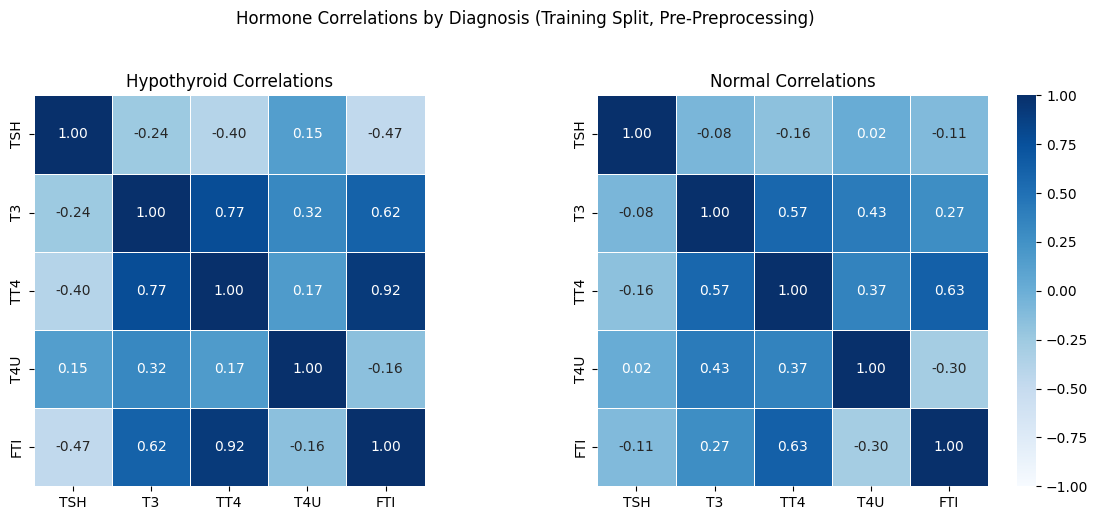

In [223]:
# We use a heatmap to quickly visualise correlations between hormone indicators
# and identify which variables move together.

corr_source = eda_train.copy()
corr_source.columns = corr_source.columns.str.strip()
corr_source["Class"] = corr_source["Class"].astype(str).str.strip().str.lower()

# Exclude TBG because it is too sparse for a stable correlation view
corr_hormones = [col for col in ["TSH", "T3", "TT4", "T4U", "FTI"] if col in corr_source.columns]

for col in corr_hormones:
    corr_source[col] = pd.to_numeric(corr_source[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vmin, vmax = -1, 1

heatmap_specs = [
    ("hypothyroid", "Hypothyroid Correlations"),
    ("negative", "Normal Correlations"),
]

for idx, (ax, (cls, title)) in enumerate(zip(axes, heatmap_specs)):
    subset = corr_source.loc[corr_source["Class"] == cls, corr_hormones]
    sns.heatmap(
        subset.corr(),
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        square=True,
        cbar=(idx == 1),
        ax=ax,
    )
    ax.set_title(title)

fig.suptitle("Hormone Correlations by Diagnosis (Training Split, Pre-Preprocessing)", y=1.03)
plt.tight_layout()
plt.show()

# TBG is not included as it has too many missing values


<b>Figure 4.</b> Correlation of Hormones. 

<p style="text-align:justify;">Hormone relationships are stronger in the hypothyroid group, particularly TT4 with FTI (0.92 vs 0.63) and T3 with TT4 (0.77 vs 0.57). The negative correlations between TSH and TT4 or FTI are also more pronounced in hypothyroid patients ( −0.40 and −0.47) than in normal individuals (−0.16 and −0.11), reflecting clearer disruption of usual thyroid regulation.</p>


<b>Note 4:</b> TBG is not included as it has too many missing values and is dropped in the Feature Engineering stage.

## 3. Prepare the Data
### Feature Engineering and Preprocessing

This section takes the training-only insights above and turns them into a modelling-ready feature space without changing the original split assignments.


### 3.1 Train-Only Clipping Strategy

**What this chunk does**

These cells estimate clipping thresholds from the training data only and then apply the learned bounds consistently to train, validation, and test.


In [224]:
# Fit train-only clipping thresholds for selected numeric columns
clip_params = {}
train_for_clipping = split_dfs_raw["train"]

for col in cfg["clip_cols"]:
    if col not in train_for_clipping.columns:
        continue
    series = pd.to_numeric(train_for_clipping[col], errors="coerce").dropna()
    if series.empty:
        continue
    q01 = float(series.quantile(0.01))
    q99 = float(series.quantile(0.99))
    clip_params[col] = {"low": q01, "high": q99}

clip_params_df = pd.DataFrame(clip_params).T
clip_params_df.index.name = "feature"
style1(clip_params_df.reset_index())


,feature,low,high
0,TSH,0.000000,133.800000
1,T3,0.300000,5.019000
2,TT4,10.000000,241.080000
3,T4U,0.359300,1.710000
4,FTI,10.000000,337.560000


In [225]:
# Apply clipping parameters to train/val/test without mutating the raw split copies
def apply_clipping(df: pd.DataFrame, clip_params: dict) -> tuple[pd.DataFrame, dict]:
    out = df.copy()
    affected = {}

    for col, bounds in clip_params.items():
        if col not in out.columns:
            affected[col] = 0
            continue

        s = pd.to_numeric(out[col], errors="coerce")
        low, high = bounds["low"], bounds["high"]

        mask = s.notna() & ((s < low) | (s > high))
        affected[col] = int(mask.sum())

        clipped = s.clip(lower=low, upper=high)
        out.loc[s.notna(), col] = clipped[s.notna()]

    return out, affected


clip_report = {}
split_dfs_clipped = {}
for split_name, sdf in split_dfs_raw.items():
    clipped_df, affected = apply_clipping(sdf, clip_params)
    split_dfs_clipped[split_name] = clipped_df
    clip_report[split_name] = affected

df_train_clipped = split_dfs_clipped["train"]
df_val_clipped = split_dfs_clipped["val"]
df_test_clipped = split_dfs_clipped["test"]

clip_report_df = pd.DataFrame(clip_report).fillna(0).astype(int)
style1(clip_report_df.reset_index().rename(columns={"index": "feature"}))


,feature,train,val,test
0,TSH,19,1,4
1,T3,33,11,7
2,TT4,36,11,14
3,T4U,39,11,12
4,FTI,39,7,12


**Output analysis**

The clipping report keeps extreme numeric values under control while preserving every patient record.
This is a better fit than dropping rows because the extreme hormone values are often part of the real disease signal.


### 3.2 Engineered Features and Feature Grouping

**What this chunk does**

The next cells add compact summary features for missingness and measurement frequency, then separate the modelling columns into numeric and categorical groups.


In [226]:
# Section 4.1: engineered features

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["age_missing"] = out["age"].isna().astype(int)

    hormone_cols = [c for c in ["TSH", "T3", "TT4", "T4U", "FTI", "TBG"] if c in out.columns]
    out["hormone_missing_count"] = out[hormone_cols].isna().sum(axis=1).astype(int)

    measured_cols = [c for c in out.columns if c.endswith("_measured")]
    if measured_cols:
        measured_is_yes = out[measured_cols].apply(
            lambda s: s.astype("string").str.strip().str.lower().eq("y")
        )
        out["measured_count"] = measured_is_yes.sum(axis=1).astype(int)
    else:
        out["measured_count"] = 0

    return out


split_dfs_enriched = {name: add_engineered_features(sdf) for name, sdf in split_dfs_clipped.items()}

df_train_enriched = split_dfs_enriched["train"]
df_val_enriched = split_dfs_enriched["val"]
df_test_enriched = split_dfs_enriched["test"]

print("Added engineered columns: age_missing, hormone_missing_count, measured_count")


Added engineered columns: age_missing, hormone_missing_count, measured_count


In [227]:
# Build train-only column groups: numeric vs categorical
excluded = {cfg["target_col"], cfg["id_col"], *cfg["drop_cols"]}
feature_cols_v1 = [c for c in df_train_enriched.columns if c not in excluded]

numeric_candidates = set(cfg["numeric_cols"] + ["age_missing", "hormone_missing_count", "measured_count"])
num_cols = [c for c in feature_cols_v1 if c in numeric_candidates]
cat_cols = [c for c in feature_cols_v1 if c not in num_cols]

print(f"Total features: {len(feature_cols_v1)}")
print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")


Total features: 27
Numeric features (9): ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'age_missing', 'hormone_missing_count', 'measured_count']
Categorical features (18): ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre', 'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured']


**Output analysis**

The engineered features capture information from entries with missing values that would otherwise stay implicit:

- `age_missing` flags absent age values directly.
- `hormone_missing_count` summarises how much laboratory information is unavailable for each patient.
- `measured_count` captures how many tests were actually performed.

The printed feature grouping also makes the later preprocessing pipeline transparent rather than burying column selection inside helper code.


### 3.3 Binary Encoding and Final Preprocessing

**What this chunk does**

These cells define the preprocessing helpers, fit the train-only transformer, encode the split datasets, preview the transformed design matrix, and confirm that the resulting matrices are finite and aligned with the targets.


In [228]:
#Preprocessing helpers
def _prepare_feature_frame(df: pd.DataFrame, num_cols: list[str], cat_cols: list[str]) -> pd.DataFrame:
    X = df[num_cols + cat_cols].copy()

    for col in num_cols:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    for col in cat_cols:
        s = X[col].astype("string")
        s = s.where(s.notna(), pd.NA)
        X[col] = s.astype(object)
        X[col] = X[col].where(pd.notna(X[col]), np.nan)

    return X


def build_preprocessor(train_df: pd.DataFrame, cfg: dict, num_cols: list[str], cat_cols: list[str]) -> ColumnTransformer:
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    # Binary-style encoding: each categorical feature becomes one encoded column.
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "binary_encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,
                dtype=np.float64
            )
        )
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, num_cols),
            ("cat", categorical_pipeline, cat_cols)
        ],
        remainder="drop"
    )

    X_train = _prepare_feature_frame(train_df, num_cols, cat_cols)
    preprocessor.fit(X_train)
    return preprocessor


def transform_splits(
    preprocessor: ColumnTransformer,
    split_dfs: dict[str, pd.DataFrame],
    num_cols: list[str],
    cat_cols: list[str],
    cfg: dict
) -> dict:
    target_col = cfg["target_col"]
    target_map = {"negative": 0, "hypothyroid": 1}

    X_out = {}
    y_out = {}
    for split_name, sdf in split_dfs.items():
        X = _prepare_feature_frame(sdf, num_cols, cat_cols)
        y = sdf[target_col].map(target_map).astype(int).to_numpy()
        X_out[split_name] = preprocessor.transform(X)
        y_out[split_name] = y

    try:
        feature_names = preprocessor.get_feature_names_out().tolist()
    except Exception:
        feature_names = [f"feature_{i}" for i in range(X_out["train"].shape[1])]

    return {
        "X": X_out,
        "y": y_out,
        "feature_names": feature_names,
        "target_map": target_map
    }


The chunk above is responsible for imputing the missing values in both numeric and categorical variables. For numeric variables, a median impute is used and categorical variables utilise the most frequent value. The additional variables of age_missing, hormone_missing_count and measured_count still preserve the missing information to distinguish real measured value from imputed value, aiming to improve recall and calibration.

The choice to impute data was made as it prevented the removal of entries from a dataset which already has a severe class imbalance.

In [229]:
#fit train-only preprocessor and transform validation/test
preprocessor = build_preprocessor(df_train_enriched, cfg, num_cols, cat_cols)

transformed = transform_splits(
    preprocessor=preprocessor,
    split_dfs=split_dfs_enriched,
    num_cols=num_cols,
    cat_cols=cat_cols,
    cfg=cfg
)

X_train_pp = transformed["X"]["train"]
X_val_pp = transformed["X"]["val"]
X_test_pp = transformed["X"]["test"]

y_train = transformed["y"]["train"]
y_val = transformed["y"]["val"]
y_test = transformed["y"]["test"]

feature_names_pp = transformed["feature_names"]
target_map = transformed["target_map"]

preprocessor_path = Path(cfg["artifact_dir"]) / "preprocessor.joblib"
preprocessor_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, preprocessor_path)

print("Transformed shapes:")
print("- X_train_pp:", X_train_pp.shape)
print("- X_val_pp:", X_val_pp.shape)
print("- X_test_pp:", X_test_pp.shape)
print("Saved preprocessor:", preprocessor_path)


Transformed shapes:
- X_train_pp: (2158, 27)
- X_val_pp: (463, 27)
- X_test_pp: (463, 27)
Saved preprocessor: artifacts\pipeline_v1\preprocessor.joblib


In [230]:
style1(pd.DataFrame(X_train_pp, columns=feature_names_pp).head())


,num__age,num__TSH,num__T3,num__TT4,num__T4U,num__FTI,num__age_missing,num__hormone_missing_count,num__measured_count,cat__sex,cat__on_thyroxine,cat__query_on_thyroxine,cat__on_antithyroid_medication,cat__thyroid_surgery,cat__query_hypothyroid,cat__query_hyperthyroid,cat__pregnant,cat__sick,cat__tumor,cat__lithium,cat__goitre,cat__TSH_measured,cat__T3_measured,cat__TT4_measured,cat__T4U_measured,cat__FTI_measured,cat__TBG_measured
0,72.000000,30.000000,0.600000,15.000000,1.480000,10.000000,0.000000,1.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,15.000000,133.800000,1.700000,19.000000,1.130000,17.000000,0.000000,1.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
2,24.000000,133.800000,0.400000,10.000000,1.040000,10.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
3,77.000000,7.300000,1.200000,57.000000,1.280000,44.000000,0.000000,1.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,85.000000,133.800000,1.100000,27.000000,1.190000,23.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


In [231]:
# Brief post-binary-encoding sanity check
def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

encoded_splits = {
    "train": (X_train_pp, y_train),
    "val": (X_val_pp, y_val),
    "test": (X_test_pp, y_test),
}

print("Post-binary-encoding sanity check")
print(f"Encoded feature count: {len(feature_names_pp)}")

for name, (X, y) in encoded_splits.items():
    X_dense = _to_dense(X)

    print(f"\n{name.upper()}")
    print(f"Rows x columns: {X_dense.shape[0]} x {X_dense.shape[1]}")
    print(f"Target length matches X: {X_dense.shape[0] == len(y)}")
    print(f"Missing values: {int(np.isnan(X_dense).sum())}")
    print(f"Infinite values: {int(np.isinf(X_dense).sum())}")

    assert X_dense.shape[0] == len(y), f"{name}: X/y row mismatch"
    assert X_dense.shape[1] == len(feature_names_pp), f"{name}: feature count mismatch"
    assert np.isfinite(X_dense).all(), f"{name}: found NaN or infinite values after encoding"

display(
    style1(pd.DataFrame(_to_dense(X_train_pp[:5]), columns=feature_names_pp).round(3))
)


Post-binary-encoding sanity check
Encoded feature count: 27

TRAIN
Rows x columns: 2158 x 27
Target length matches X: True
Missing values: 0
Infinite values: 0

VAL
Rows x columns: 463 x 27
Target length matches X: True
Missing values: 0
Infinite values: 0

TEST
Rows x columns: 463 x 27
Target length matches X: True
Missing values: 0
Infinite values: 0


,num__age,num__TSH,num__T3,num__TT4,num__T4U,num__FTI,num__age_missing,num__hormone_missing_count,num__measured_count,cat__sex,cat__on_thyroxine,cat__query_on_thyroxine,cat__on_antithyroid_medication,cat__thyroid_surgery,cat__query_hypothyroid,cat__query_hyperthyroid,cat__pregnant,cat__sick,cat__tumor,cat__lithium,cat__goitre,cat__TSH_measured,cat__T3_measured,cat__TT4_measured,cat__T4U_measured,cat__FTI_measured,cat__TBG_measured
0,72.000000,30.000000,0.600000,15.000000,1.480000,10.000000,0.000000,1.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,15.000000,133.800000,1.700000,19.000000,1.130000,17.000000,0.000000,1.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
2,24.000000,133.800000,0.400000,10.000000,1.040000,10.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
3,77.000000,7.300000,1.200000,57.000000,1.280000,44.000000,0.000000,1.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,85.000000,133.800000,1.100000,27.000000,1.190000,23.000000,0.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


**Output analysis**

The transformed feature space contains **27 features** for each split.
The sanity checks show that all three encoded matrices have the expected row counts, no missing values, and no infinite values, which means the preprocessing stage has successfully converted the mixed clinical data into a stable modelling input.


## 4. Model Selection and Baseline Exploration

Logistic regression is a credible baseline because the task is binary diagnosis from structured clinical measurements. In hypothyroid.csv, lab variables show clear class separation (e.g., median TSH 36.0 vs 0.6; TT4 33.0 vs 106.0; FTI 34.0 vs 109.0), so a linear probabilistic model is a sensible first benchmark, and its probabilities can be thresholded for clinical priorities. Boosting is a strong comparison because diagnosis may depend on non-linear cut-offs and interactions. The dataset also encodes MNAR via flags: TSH is recorded in 99.3% vs 84.5%, and TT4/FTI in 100% vs 91.8% - patterns that boosted trees model well.


### 4.1 Target Distribution and Model Inputs

**What this chunk does**

These cells compute class-weight information from the training target and package the encoded split data into the structures expected by the downstream sklearn, XGBoost, and LightGBM APIs.


In [232]:
# final target extraction + class-weight summary
from sklearn.utils.class_weight import compute_class_weight

# y_* already aligned with transformed matrices from cell 64
n_train = int(len(y_train))
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())

if n_pos == 0:
    raise ValueError("y_train has zero positive examples; class-weight statistics cannot be computed.")

classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_stats = {
    "n_train": n_train,
    "n_negative": n_neg,
    "n_positive": n_pos,
    "positive_prevalence": float(n_pos / n_train),
    "scale_pos_weight": float(n_neg / n_pos),
    "class_weight_balanced": {int(cls): float(w) for cls, w in zip(classes, weights)}
}

print(json.dumps(class_weight_stats, indent=2, default=_json_default))


{
  "n_train": 2158,
  "n_negative": 2060,
  "n_positive": 98,
  "positive_prevalence": 0.04541241890639481,
  "scale_pos_weight": 21.020408163265305,
  "class_weight_balanced": {
    "0": 0.5237864077669903,
    "1": 11.010204081632653
  }
}


In [233]:
# Build modeling-ready containers without training models
model_inputs_v1 = {
    "X_train": X_train_pp,
    "X_val": X_val_pp,
    "X_test": X_test_pp,
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
    "feature_names": feature_names_pp,
    "target_map": target_map,
    "class_weight_stats": class_weight_stats,
    "split_ids": split_ids
}

# Optional wrappers for downstream model APIs
xgb_dmats = {}
try:
    xgb_dmats["train"] = xgb.DMatrix(X_train_pp, label=y_train, feature_names=feature_names_pp)
    xgb_dmats["val"] = xgb.DMatrix(X_val_pp, label=y_val, feature_names=feature_names_pp)
    xgb_dmats["test"] = xgb.DMatrix(X_test_pp, label=y_test, feature_names=feature_names_pp)
except Exception as exc:
    xgb_dmats = {"error": str(exc)}

lgb_datasets = {}
try:
    lgb_datasets["train"] = lgb.Dataset(X_train_pp, label=y_train, feature_name=feature_names_pp, free_raw_data=False)
    lgb_datasets["val"] = lgb.Dataset(X_val_pp, label=y_val, feature_name=feature_names_pp, reference=lgb_datasets["train"], free_raw_data=False)
except Exception as exc:
    lgb_datasets = {"error": str(exc)}

model_inputs_v1["xgb_dmats"] = xgb_dmats
model_inputs_v1["lgb_datasets"] = lgb_datasets

model_input_summary = {
    "X_shapes": {
        "train": list(X_train_pp.shape),
        "val": list(X_val_pp.shape),
        "test": list(X_test_pp.shape)
    },
    "feature_count": len(feature_names_pp),
    "class_weight_stats": class_weight_stats
}

artifact_dir = Path(cfg["artifact_dir"])
artifact_dir.mkdir(parents=True, exist_ok=True)
(artifact_dir / "model_input_summary.json").write_text(
    json.dumps(model_input_summary, indent=2, default=_json_default),
    encoding="utf-8"
)

manifest = update_manifest(
    {
        "post_preprocessing": {
            "feature_count": len(feature_names_pp),
            "transformed_shapes": model_input_summary["X_shapes"],
            "class_weight_stats": class_weight_stats,
            "preprocessor_path": str(artifact_dir / "preprocessor.joblib")
        },
        "reports_written": sorted(
            set(manifest.get("reports_written", []) + ["leakage_report.json", "model_input_summary.json"])
        )
    },
    cfg
)

print("Modeling-ready containers prepared.")
print("Manifest updated at:", artifact_dir / "manifest.json")


Modeling-ready containers prepared.
Manifest updated at: artifacts\pipeline_v1\manifest.json


**Output analysis**

The training split contains **98 positive** cases versus **2,060 negative** cases, implying a `scale_pos_weight` of about **21.02**.
That is exactly the kind of imbalance that can bury recall if the models are trained and scored with default assumptions.


### 4.2 Baseline Models at the Initial Fixed Threshold

**What this chunk does**

The following cells train three baseline candidates, evaluate them on the validation set, plot the validation confusion matrices, and then check how the same models behave on the held-out test set.


In [234]:
n_features = X_train_pp.shape[1]
n_train = len(y_train)
n_val = len(y_val)
n_test = len(y_test)
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())

assert len(feature_names_pp) == n_features, (
    f"feature_names_pp has {len(feature_names_pp)} names but X_train_pp has {n_features} columns."
)
assert X_val_pp.shape[1] == n_features, "Validation feature count does not match training."
assert X_test_pp.shape[1] == n_features, "Test feature count does not match training."
assert n_pos + n_neg == n_train, "Training class counts do not sum to training size."

print("Runtime data summary:")
print(f"- features: {n_features}")
print(f"- train shape: {X_train_pp.shape}")
print(f"- val shape: {X_val_pp.shape}")
print(f"- test shape: {X_test_pp.shape}")
print(f"- train positives: {n_pos}")
print(f"- train negatives: {n_neg}")
print(json.dumps(class_weight_stats, indent=2))

trained_models = {}
val_probabilities = {}
test_probabilities = {}
val_predictions = {}
test_predictions = {}

logistic_model = SkPipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    (
        "model",
        LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train_pp, y_train)

trained_models["Logistic Regression"] = logistic_model
val_probabilities["Logistic Regression"] = logistic_model.predict_proba(X_val_pp)[:, 1]
test_probabilities["Logistic Regression"] = logistic_model.predict_proba(X_test_pp)[:, 1]

print("Completed:", list(trained_models.keys()))
print("Validation probabilities:", val_probabilities["Logistic Regression"].shape)
print("Test probabilities:", test_probabilities["Logistic Regression"].shape)


Runtime data summary:
- features: 27
- train shape: (2158, 27)
- val shape: (463, 27)
- test shape: (463, 27)
- train positives: 98
- train negatives: 2060
{
  "n_train": 2158,
  "n_negative": 2060,
  "n_positive": 98,
  "positive_prevalence": 0.04541241890639481,
  "scale_pos_weight": 21.020408163265305,
  "class_weight_balanced": {
    "0": 0.5237864077669903,
    "1": 11.010204081632653
  }
}
Completed: ['Logistic Regression']
Validation probabilities: (463,)
Test probabilities: (463,)


In [235]:
if not isinstance(xgb_dmats, dict) or ("error" in xgb_dmats):
    xgb_dmats = {
        "train": xgb.DMatrix(X_train_pp, label=y_train, feature_names=feature_names_pp),
        "val": xgb.DMatrix(X_val_pp, label=y_val, feature_names=feature_names_pp),
        "test": xgb.DMatrix(X_test_pp, label=y_test, feature_names=feature_names_pp)
    }

#Codex suggested model parameters based on class imbalance stats, with a focus on controlling overfitting and leveraging balanced class weights. 
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": ["aucpr", "auc", "logloss"],
    "eta": 0.05,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "gamma": 0.0,
    "scale_pos_weight": float(class_weight_stats["scale_pos_weight"]),
    "tree_method": "hist",
    "seed": 42
}

xgb_model = xgb.train(
    params=xgb_params,
    dtrain=xgb_dmats["train"],
    num_boost_round=200,
    evals=[(xgb_dmats["train"], "train")],
    verbose_eval=False
)

trained_models["XGBoost"] = xgb_model
val_probabilities["XGBoost"] = xgb_model.predict(xgb_dmats["val"])
test_probabilities["XGBoost"] = xgb_model.predict(xgb_dmats["test"])

print("Completed:", list(trained_models.keys()))
print("Validation probabilities:", val_probabilities["XGBoost"].shape)
print("Test probabilities:", test_probabilities["XGBoost"].shape)


Completed: ['Logistic Regression', 'XGBoost']
Validation probabilities: (463,)
Test probabilities: (463,)


In [236]:
if not isinstance(lgb_datasets, dict) or ("error" in lgb_datasets):
    lgb_datasets = {
        "train": lgb.Dataset(X_train_pp, label=y_train, feature_name=feature_names_pp, free_raw_data=False),
        "val": lgb.Dataset(X_val_pp, label=y_val, feature_name=feature_names_pp, free_raw_data=False),
        "test": lgb.Dataset(X_test_pp, label=y_test, feature_name=feature_names_pp, free_raw_data=False)
    }
#Codex suggested model parameters based on class imbalance stats, with a focus on controlling overfitting and leveraging balanced class weights. 
lgb_params = {
    "objective": "binary",
    "metric": ["average_precision", "auc", "binary_logloss"],
    "learning_rate": 0.05,
    "num_leaves": 15,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l2": 1.0,
    "scale_pos_weight": float(class_weight_stats["scale_pos_weight"]),
    "verbosity": -1,
    "seed": 42
}

lgb_model = lgb.train(
    params=lgb_params,
    train_set=lgb_datasets["train"],
    num_boost_round=200
)

trained_models["LightGBM"] = lgb_model
val_probabilities["LightGBM"] = lgb_model.predict(X_val_pp)
test_probabilities["LightGBM"] = lgb_model.predict(X_test_pp)

print("Completed:", list(trained_models.keys()))
print("Validation probabilities:", val_probabilities["LightGBM"].shape)
print("Test probabilities:", test_probabilities["LightGBM"].shape)


Completed: ['Logistic Regression', 'XGBoost', 'LightGBM']
Validation probabilities: (463,)
Test probabilities: (463,)


In [237]:

def evaluate_binary_predictions(y_true, y_prob, threshold=0.8):
    y_prob = np.asarray(y_prob, dtype=float)
    if np.isnan(y_prob).any():
        raise ValueError("Predicted probabilities contain NaN values.")

    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

def plot_confusion_matrices(results_dict, y_true, threshold=0.8, title_prefix="Validation"):
    model_names = list(results_dict.keys())
    fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4))
    if len(model_names) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, model_names):
        y_pred = (np.asarray(results_dict[model_name]) >= threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(model_name)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_xticklabels(["Negative", "Hypothyroid"], rotation=0)
        ax.set_yticklabels(["Negative", "Hypothyroid"], rotation=0)

    fig.suptitle(f"{title_prefix} Confusion Matrices (threshold={threshold:.2f})", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()


In [238]:
assert all(len(np.asarray(prob)) == len(y_val) for prob in val_probabilities.values()), \
    "Each model must return 463 validation probabilities."
assert all(np.isfinite(np.asarray(prob)).all() for prob in val_probabilities.values()), \
    "Validation probabilities contain non-finite values."

val_predictions = {
    name: (np.asarray(prob) >= 0.8).astype(int)
    for name, prob in val_probabilities.items()
}

validation_rows = []
for model_name, probs in val_probabilities.items():
    row = evaluate_binary_predictions(y_val, probs, threshold=0.8)
    row["model"] = model_name
    validation_rows.append(row)

validation_metrics_df = pd.DataFrame(validation_rows)
validation_metrics_df = validation_metrics_df[
    ["model", "threshold", "recall", "precision", "f1", "specificity",
     "balanced_accuracy", "pr_auc", "roc_auc", "log_loss", "tn", "fp", "fn", "tp"]
]
validation_metrics_df = validation_metrics_df.sort_values(
    by=["recall", "pr_auc", "balanced_accuracy"],
    ascending=[False, False, False]
).reset_index(drop=True)

assert validation_metrics_df.shape[0] == 3, \
    f"Expected 3 validation rows, found {validation_metrics_df.shape[0]}."

display(style1(validation_metrics_df))



,model,threshold,recall,precision,f1,specificity,balanced_accuracy,pr_auc,roc_auc,log_loss,tn,fp,fn,tp
0,Logistic Regression,0.800000,1.000000,0.807692,0.893617,0.988688,0.994344,0.993592,0.999677,0.080045,437,5,0,21
1,XGBoost,0.800000,1.000000,0.875000,0.933333,0.993213,0.996606,0.981446,0.999138,0.035347,439,3,0,21
2,LightGBM,0.800000,0.952381,0.833333,0.888889,0.990950,0.971666,0.988052,0.999354,0.030016,438,4,1,20


<b>Figure 5a.</b> Model Performance Metrics for Validation Set 

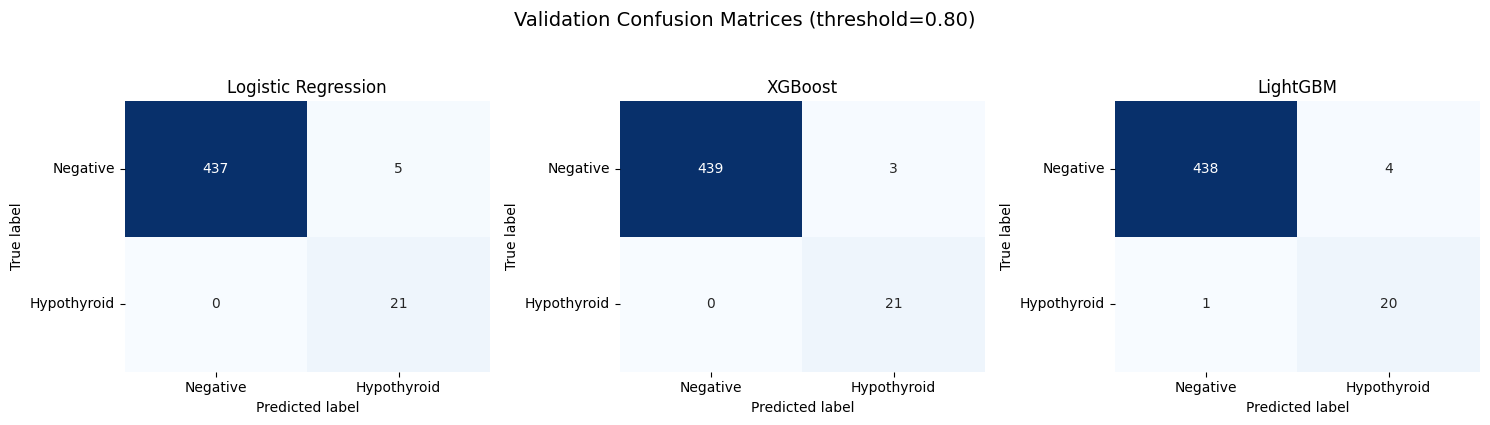

In [239]:
plot_confusion_matrices(
    val_probabilities,
    y_val,
    threshold=0.8,
    title_prefix="Validation"
)

<b>Figure 5b.</b> Model Confusion Matrix for Validation Set 

On the validation set (threshold = 0.80), all three models show excellent overall discrimination (ROC AUC ≈ 0.999), suggesting the lab features separate hypothyroid vs negative cases very well. In a clinical screening context where recall/sensitivity is paramount, both Logistic Regression and XGBoost achieve 100% recall (FN=0; TP=21), meaning no hypothyroid cases were missed at this operating point. LightGBM is slightly less safe for screening with 95.2% recall (FN=1; TP=20). Among the two perfect-recall models, XGBoost provides the best precision–burden trade-off, with higher precision (0.875 vs 0.808) and fewer false positives (FP=3 vs 5), which translates to fewer unnecessary follow-ups while still catching every case. This is reflected in its stronger F1 (0.933) and slightly higher balanced accuracy (0.9966). Both boosting models also have lower log loss, implying better-calibrated probability outputs, which is beneficial for threshold optimization when trading off sensitivity versus false-positive workload.

### 4.3 Baseline Evaluation Plots

**What this chunk does**

These helper definitions and plots compare ROC, precision-recall, and threshold trade-off behaviour for the baseline validation predictions.


In [240]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def plot_roc_curves(prob_dict, y_true, title="ROC Curves"):
    plt.figure(figsize=(8, 6))

    for model_name, y_prob in prob_dict.items():
        y_prob = np.asarray(y_prob, dtype=float)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()


In [241]:
def plot_pr_curves(prob_dict, y_true, title="Precision-Recall Curves"):
    plt.figure(figsize=(8, 6))

    positive_rate = np.mean(y_true)
    plt.axhline(
        positive_rate,
        linestyle="--",
        color="grey",
        linewidth=1,
        label=f"Baseline prevalence = {positive_rate:.3f}"
    )

    for model_name, y_prob in prob_dict.items():
        y_prob = np.asarray(y_prob, dtype=float)
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        plt.plot(recall, precision, linewidth=2, label=f"{model_name} (AP = {ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.show()


In [242]:
def plot_precision_recall_tradeoff(prob_dict, y_true, title_prefix="Precision-Recall Tradeoff"):
    n_models = len(prob_dict)
    fig, axes = plt.subplots(n_models, 1, figsize=(8, 4 * n_models), sharex=False)

    if n_models == 1:
        axes = [axes]

    for ax, (model_name, y_prob) in zip(axes, prob_dict.items()):
        y_prob = np.asarray(y_prob, dtype=float)
        precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

        ax.plot(thresholds, precision[:-1], label="Precision", linewidth=2)
        ax.plot(thresholds, recall[:-1], label="Recall", linewidth=2)
        ax.axvline(0.8, linestyle="--", color="black", linewidth=1, label="Threshold = 0.80")

        ax.set_title(f"{title_prefix}: {model_name}")
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
        ax.legend(loc="best")

    plt.tight_layout()
    plt.show()


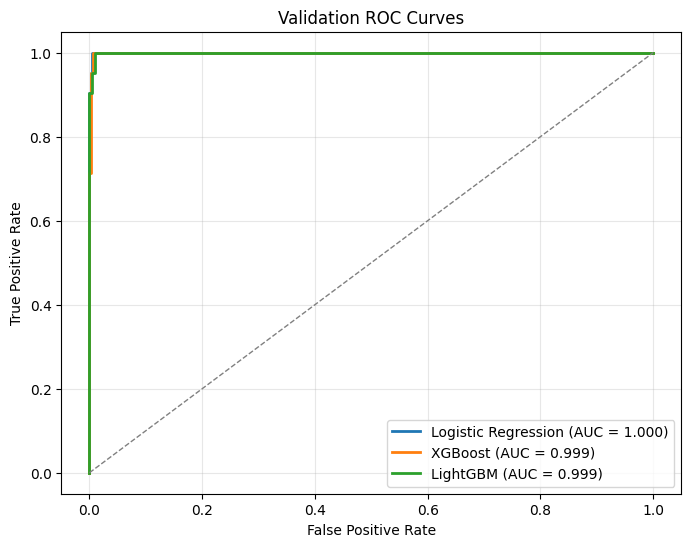

In [243]:
plot_roc_curves(val_probabilities, y_val, title="Validation ROC Curves")

**Figure 6** presents the validation ROC curves for each model, with AUC values of approximately 1.000 for Logistic Regression and 0.999 for both XGBoost and LightGBM. This indicates that, across a wide range of thresholds, the models separate hypothyroid from negative cases extremely well in terms of ranking. In practical tuning terms, these near-ceiling ROC results suggest that further gains from hyperparameter optimisation may be marginal, and that model selection is more likely to be driven by threshold behaviour, calibration, and the downstream cost of false positives versus false negatives in a clinical workflow.

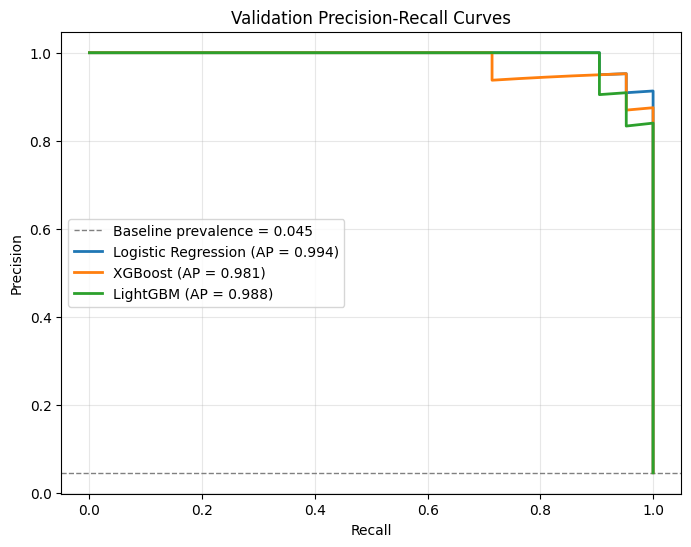

In [244]:
plot_pr_curves(val_probabilities, y_val, title="Validation Precision-Recall Curves")

**Figure 7** plots the Validation Precision–recall (PR) curves alongside the baseline prevalence (0.045), which is particularly relevant under class imbalance. All models achieve very high average precision (AP ≈ 0.981–0.994), indicating that positive predictions remain informative even when recall is pushed higher. Compared with ROC, PR performance is more sensitive to the false-positive burden, making it better aligned with clinical triage where unnecessary follow-up testing carries extra operational cost. For tuning, these curves support selecting an operating point by targeting a clinically acceptable sensitivity (e.g., near-complete case capture) and then choosing the threshold that minimises false positives.

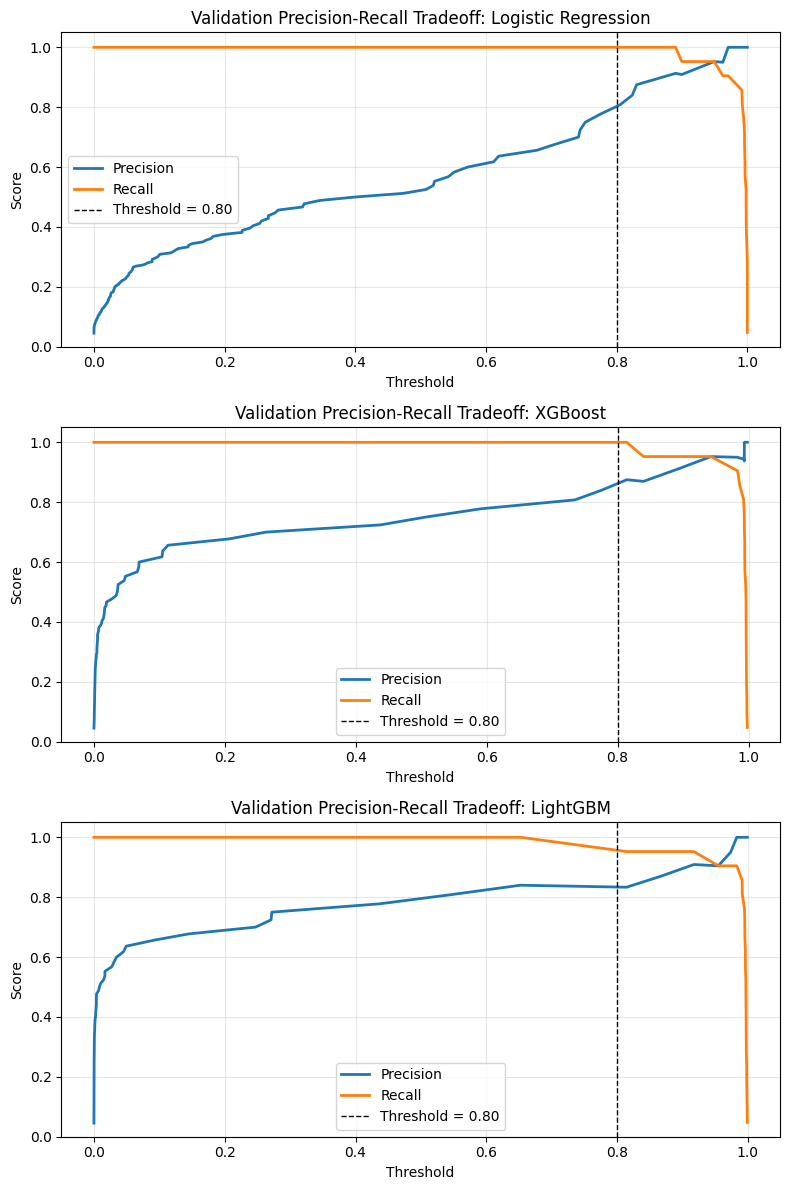

In [245]:
plot_precision_recall_tradeoff(val_probabilities, y_val, title_prefix="Validation Precision-Recall Tradeoff")


**Figure 8** visualises how precision and recall change as the decision threshold varies, with the initial threshold of 0.80 marked for reference. As expected, increasing the threshold generally improves precision but eventually reduces recall, highlighting a clinically important trade-off between missed cases and additional investigations. Notably, recall remains at 1.0 around a 0.80 threshold for Logistic Regression and XGBoost, whereas LightGBM shows an earlier decline, suggesting that its sensitivity is more fragile at this operating point. These patterns imply that threshold tuning, potentially supported by probability calibration, may be more impactful than further model complexity, and that the final threshold should be chosen to avoid regions where small shifts in score distribution could cause disproportionate losses in recall on external data.

## 5. Fine Tune & Evaluate

This section retrains the three candidates, tunes each classification threshold on the validation set, and then digs into calibration, residual-style errors, failure modes, and feature importance.


### 5.1 Validation-Set Threshold Search

For tuning, the focus was on a robust minority-class detection alongside a clinically defensible operating point. All models were retrained using Codex-suggested imbalance-aware weighting and regularisation. Both boosting models were also constrained using small learning rates, shallow trees and early stopping to reduce overfitting whilst preserving sensitivity.  

For threshold selection, values were systematically swept **(0.50–0.98)** at increments of **0.01** and selected via a screening-first rule that prioritised minimising false negatives and maximising recall before considering precision/specificity.



In [246]:
#Codex - recommended hyperparameters for final training runs based on validation performance and class-weight statistics

# Reset containers
trained_models = {}
val_probabilities = {}
test_probabilities = {}
val_predictions = {}
test_predictions = {}

# -----------------------------
# 1. Logistic Regression
# -----------------------------
logistic_model = SkPipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    (
        "model",
        LogisticRegression(
            penalty="l2",
            C=0.25,
            solver="liblinear",
            class_weight={0: 1, 1: 6},
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train_pp, y_train)

trained_models["Logistic Regression"] = logistic_model
val_probabilities["Logistic Regression"] = logistic_model.predict_proba(X_val_pp)[:, 1]
test_probabilities["Logistic Regression"] = logistic_model.predict_proba(X_test_pp)[:, 1]

print("Completed: Logistic Regression")


# -----------------------------
# 2. XGBoost
# -----------------------------
xgb_dmats = {
    "train": xgb.DMatrix(X_train_pp, label=y_train, feature_names=feature_names_pp),
    "val": xgb.DMatrix(X_val_pp, label=y_val, feature_names=feature_names_pp),
    "test": xgb.DMatrix(X_test_pp, label=y_test, feature_names=feature_names_pp)
}

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": ["aucpr", "auc", "logloss"],
    "eta": 0.03,
    "max_depth": 2,
    "min_child_weight": 8,
    "subsample": 0.9,
    "colsample_bytree": 0.7,
    "lambda": 3.0,
    "alpha": 1.0,
    "gamma": 1.0,
    "scale_pos_weight": 12.0,
    "tree_method": "hist",
    "seed": 42
}

xgb_model = xgb.train(
    params=xgb_params,
    dtrain=xgb_dmats["train"],
    num_boost_round=400,
    evals=[(xgb_dmats["train"], "train"), (xgb_dmats["val"], "val")],
    early_stopping_rounds=30,
    verbose_eval=False
)

trained_models["XGBoost"] = xgb_model
val_probabilities["XGBoost"] = xgb_model.predict(xgb_dmats["val"])
test_probabilities["XGBoost"] = xgb_model.predict(xgb_dmats["test"])

print("Completed: XGBoost")


# -----------------------------
# 3. LightGBM
# -----------------------------
lgb_train = lgb.Dataset(
    X_train_pp,
    label=y_train,
    feature_name=feature_names_pp,
    free_raw_data=False
)

lgb_val = lgb.Dataset(
    X_val_pp,
    label=y_val,
    feature_name=feature_names_pp,
    reference=lgb_train,
    free_raw_data=False
)

lgb_params = {
    "objective": "binary",
    "metric": ["average_precision", "auc", "binary_logloss"],
    "learning_rate": 0.03,
    "num_leaves": 7,
    "max_depth": 3,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.9,
    "bagging_freq": 1,
    "lambda_l1": 1.0,
    "lambda_l2": 5.0,
    "min_gain_to_split": 0.2,
    "scale_pos_weight": 12.0,
    "verbosity": -1,
    "seed": 42
}

lgb_model = lgb.train(
    params=lgb_params,
    train_set=lgb_train,
    num_boost_round=400,
    valid_sets=[lgb_train, lgb_val],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)

trained_models["LightGBM"] = lgb_model
val_probabilities["LightGBM"] = lgb_model.predict(X_val_pp, num_iteration=lgb_model.best_iteration)
test_probabilities["LightGBM"] = lgb_model.predict(X_test_pp, num_iteration=lgb_model.best_iteration)

print("Completed: LightGBM")

print("Trained models:", list(trained_models.keys()))
print("Validation probability shapes:", {k: np.asarray(v).shape for k, v in val_probabilities.items()})
print("Test probability shapes:", {k: np.asarray(v).shape for k, v in test_probabilities.items()})


Completed: Logistic Regression
Completed: XGBoost
Completed: LightGBM
Trained models: ['Logistic Regression', 'XGBoost', 'LightGBM']
Validation probability shapes: {'Logistic Regression': (463,), 'XGBoost': (463,), 'LightGBM': (463,)}
Test probability shapes: {'Logistic Regression': (463,), 'XGBoost': (463,), 'LightGBM': (463,)}


### Validation-set threshold search
This table shows the threshold selected for each model using the **validation set** under the **false-negative minimisation rule**.

,model,threshold,recall,precision,f1,specificity,balanced_accuracy,pr_auc,roc_auc,log_loss,tn,fp,fn,tp
0,Logistic Regression,0.760000,1.000000,0.954545,0.976744,0.997738,0.998869,0.995568,0.999785,0.039086,441,1,0,21
1,XGBoost,0.690000,1.000000,0.840000,0.913043,0.990950,0.995475,0.962596,0.998492,0.035786,438,4,0,21
2,LightGBM,0.520000,0.952381,0.869565,0.909091,0.993213,0.972797,0.926997,0.998007,0.064863,439,3,1,20


### Thresholds used for test-set confusion matrices
Each confusion matrix below is computed on the **held-out test set**, using the threshold selected earlier from the **validation set** for that model.

,model,threshold
0,Logistic Regression,0.760000
1,XGBoost,0.690000
2,LightGBM,0.520000


### Test-set confusion matrices
These confusion matrices are computed on the **test set**, not the validation set. Therefore, the counts shown below will not exactly match the validation-set table above.

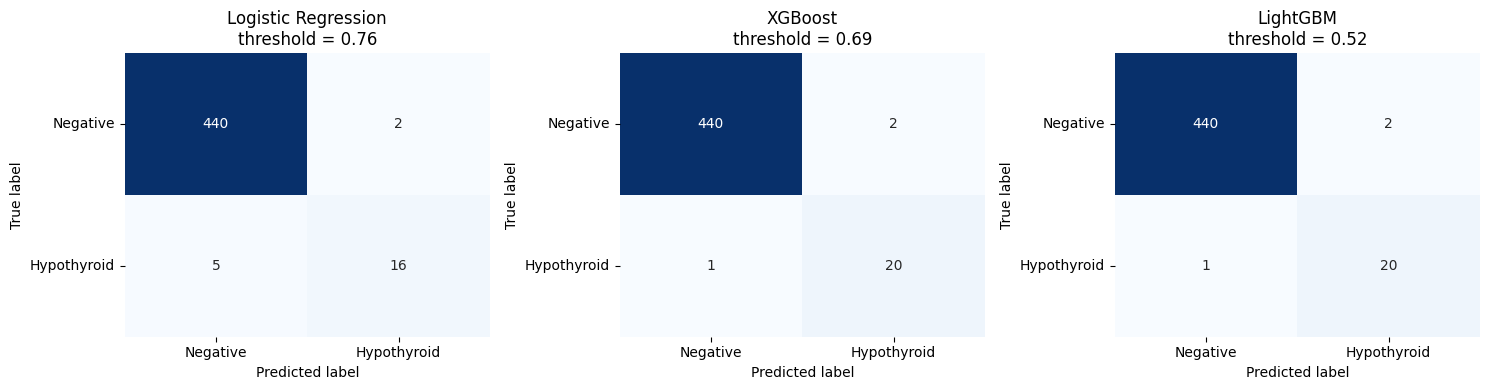

In [247]:


def evaluate_binary_predictions(y_true, y_prob, threshold):
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "log_loss": float(log_loss(y_true, y_prob, labels=[0, 1])),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

# ----------------------------------------
# Threshold search on validation set
# ----------------------------------------
threshold_grid = np.round(np.arange(0.50, 0.99, 0.01), 2)

search_rows = []

for model_name, probs in val_probabilities.items():
    probs = np.asarray(probs, dtype=float)

    for threshold in threshold_grid:
        row = evaluate_binary_predictions(y_val, probs, threshold=threshold)
        row["model"] = model_name
        search_rows.append(row)

search_df = pd.DataFrame(search_rows)

# Best threshold per model:
# 1. lowest FN
# 2. highest recall
# 3. highest precision
# 4. highest specificity
# 5. highest threshold
best_per_model_df = (
    search_df
    .sort_values(
        by=["model", "fn", "recall", "precision", "specificity", "threshold"],
        ascending=[True, True, False, False, False, False]
    )
    .groupby("model", as_index=False)
    .first()
    .sort_values(
        by=["fn", "recall", "precision", "specificity"],
        ascending=[True, False, False, False]
    )
    .reset_index(drop=True)
)
#Codex-generated markdown structure to introduce details before the table output
display(Markdown(
    "### Validation-set threshold search\n"
    "This table shows the threshold selected for each model using the **validation set** "
    "under the **false-negative minimisation rule**."
))
display(style1(best_per_model_df[
    ["model", "threshold", "recall", "precision", "f1", "specificity",
     "balanced_accuracy", "pr_auc", "roc_auc", "log_loss", "tn", "fp", "fn", "tp"]
]))

#Codex-generated markdown structure to introduce details before the table output
display(Markdown(
    "### Thresholds used for test-set confusion matrices\n"
    "Each confusion matrix below is computed on the **held-out test set**, "
    "using the threshold selected earlier from the **validation set** for that model."
))
display(style1(best_per_model_df[["model", "threshold"]]))

display(Markdown(
    "### Test-set confusion matrices\n"
    "These confusion matrices are computed on the **test set**, not the validation set. "
    "Therefore, the counts shown below will not exactly match the validation-set table above."
))

# ----------------------------------------
# Confusion matrices for all 3 models on test set
# ----------------------------------------
selected_thresholds = dict(zip(best_per_model_df["model"], best_per_model_df["threshold"]))

fig, axes = plt.subplots(1, len(test_probabilities), figsize=(5 * len(test_probabilities), 4))
if len(test_probabilities) == 1:
    axes = [axes]

for ax, model_name in zip(axes, test_probabilities.keys()):
    probs = np.asarray(test_probabilities[model_name], dtype=float)
    threshold = float(selected_thresholds[model_name])
    y_pred = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{model_name}\nthreshold = {threshold:.2f}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticklabels(["Negative", "Hypothyroid"])
    ax.set_yticklabels(["Negative", "Hypothyroid"], rotation=0)

plt.tight_layout()
plt.show()



**Figure 10** shows these fixed thresholds were applied to the test set, performance diverged, suggesting a calibration or distribution shift. Logistic Regression at 0.89 missed 5 hypothyroid cases (FN = 5, TP = 16), reducing recall to 0.76 despite 4 FPs. XGBoost at 0.81 stayed closest to the screening aim (FN = 1, TP = 20) with 1 false positive, while LightGBM (0.65) yielded 2 FNs and 2 FPs.


### 5.2 Calibration and Residual-Style Error Review

**What this chunk does**

These cells assess probability calibration on the test set, inspect the hardest cases for the recommended model, and show where the remaining mistakes are concentrated.


### Calibration
These reliability curves compare predicted probabilities with observed event frequencies on the test set.

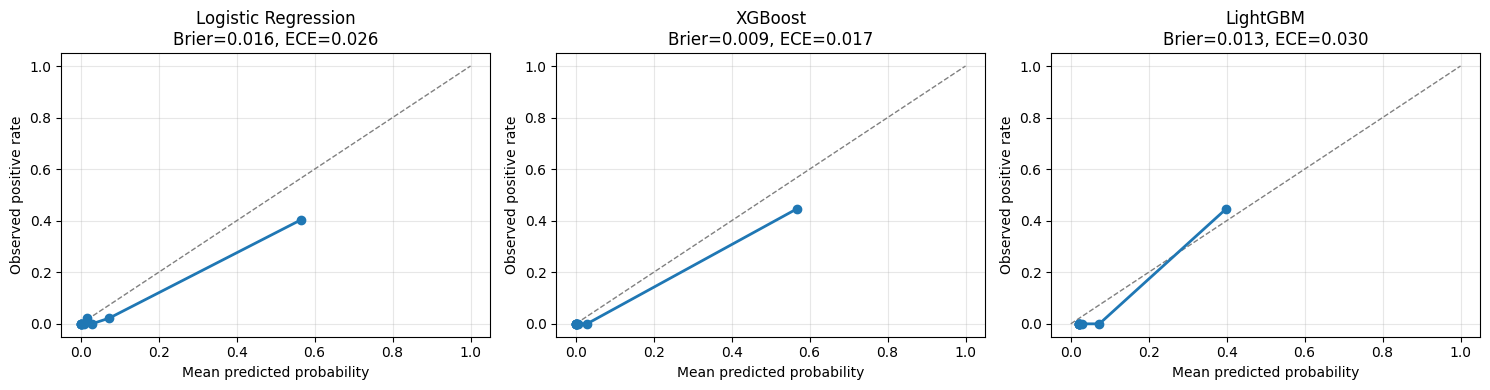

In [255]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

display(Markdown(
    "### Calibration\n"
    "These reliability curves compare predicted probabilities with observed event frequencies on the test set."
))

def build_quantile_calibration_table(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)

    bin_codes = pd.qcut(
        pd.Series(y_prob, name="y_prob"),
        q=min(n_bins, len(y_prob)),
        labels=False,
        duplicates="drop",
    )

    calib_df = (
        pd.DataFrame({"y_true": y_true, "y_prob": y_prob, "bin": bin_codes})
        .groupby("bin", dropna=True)
        .agg(
            count=("y_true", "size"),
            mean_pred=("y_prob", "mean"),
            frac_pos=("y_true", "mean"),
        )
        .reset_index(drop=True)
    )

    calib_df["abs_gap"] = (calib_df["frac_pos"] - calib_df["mean_pred"]).abs()
    calib_df["ece_component"] = calib_df["abs_gap"] * calib_df["count"] / len(y_true)
    return calib_df

ece_tables = {}
test_eval_rows = []

fig, axes = plt.subplots(1, len(test_probabilities), figsize=(5 * len(test_probabilities), 4))
if len(test_probabilities) == 1:
    axes = [axes]

for ax, model_name in zip(axes, test_probabilities.keys()):
    probs = np.asarray(test_probabilities[model_name], dtype=float)
    calib_df = build_quantile_calibration_table(y_test, probs, n_bins=10)
    ece_tables[model_name] = calib_df

    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
    brier = float(brier_score_loss(y_test, probs))
    ece = float(calib_df["ece_component"].sum())

    test_eval_rows.append({
        "model": model_name,
        "brier_score": brier,
        "ece": ece,
    })

    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
    ax.plot(mean_pred, frac_pos, marker="o", linewidth=2)
    ax.set_title(f"{model_name}\nBrier={brier:.3f}, ECE={ece:.3f}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive rate")
    ax.grid(alpha=0.3)

test_eval_df = pd.DataFrame(test_eval_rows)

plt.tight_layout()
plt.show()


The calibration curves in **Figure 11** compare each model’s predicted probabilities with the observed event rate,displaying perfect calibration with the dotted-line whilst points below indicate overconfidence. Overall calibration is strong, with low Brier scores and ECE values, but the curves suggest some overprediction at higher risk levels, most notably for Logistic Regression. XGBoost shows the best calibration (Brier=0.009, ECE=0.017), consistent with more reliable threshold transfer, while LightGBM is slightly less stable (ECE=0.030).

### Residual-style error analysis: XGBoost

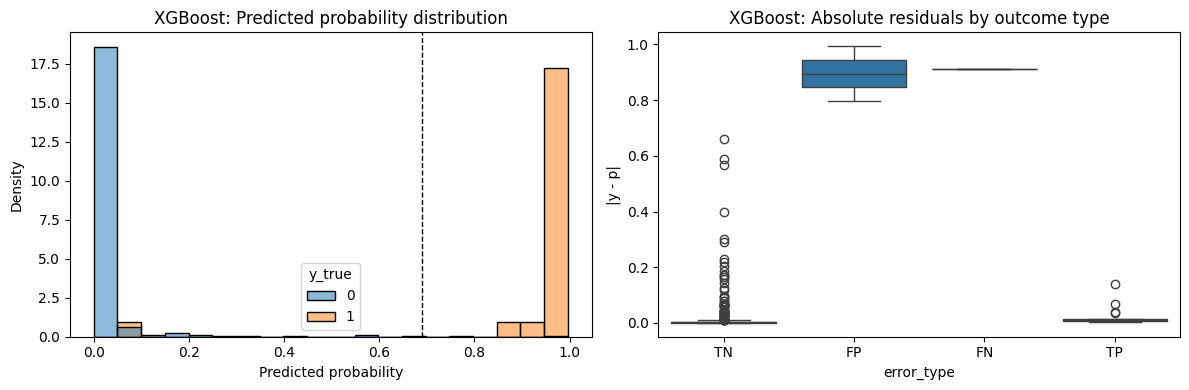

#### Hardest cases

,y_true,pred_prob,pred_label,residual,abs_residual,error_type
0,0,0.993284,1,-0.993284,0.993284,FP
1,1,0.088716,0,0.911284,0.911284,FN
2,0,0.796256,1,-0.796256,0.796256,FP
3,0,0.659368,0,-0.659368,0.659368,TN
4,0,0.587758,0,-0.587758,0.587758,TN
5,0,0.568556,0,-0.568556,0.568556,TN
6,0,0.400010,0,-0.400010,0.400010,TN
7,0,0.302740,0,-0.302740,0.302740,TN
8,0,0.290545,0,-0.290545,0.290545,TN
9,0,0.231299,0,-0.231299,0.231299,TN


In [253]:
analysis_model_name = "XGBoost"

if analysis_model_name not in selected_thresholds:
    raise KeyError(f"{analysis_model_name} not found in selected_thresholds.")
if analysis_model_name not in test_probabilities:
    raise KeyError(f"{analysis_model_name} not found in test_probabilities.")

display(Markdown(f"### Residual-style error analysis: {analysis_model_name}"))

best_threshold = float(selected_thresholds[analysis_model_name])
best_probs = np.asarray(test_probabilities[analysis_model_name], dtype=float)
best_pred = (best_probs >= best_threshold).astype(int)

error_df = pd.DataFrame({
    "y_true": np.asarray(y_test, dtype=int),
    "pred_prob": best_probs,
    "pred_label": best_pred
})
error_df["residual"] = error_df["y_true"] - error_df["pred_prob"]
error_df["abs_residual"] = error_df["residual"].abs()

conditions = [
    (error_df["y_true"] == 0) & (error_df["pred_label"] == 0),
    (error_df["y_true"] == 0) & (error_df["pred_label"] == 1),
    (error_df["y_true"] == 1) & (error_df["pred_label"] == 0),
    (error_df["y_true"] == 1) & (error_df["pred_label"] == 1),
]
labels = ["TN", "FP", "FN", "TP"]
error_df["error_type"] = np.select(conditions, labels, default="Other")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=error_df,
    x="pred_prob",
    hue="y_true",
    bins=20,
    stat="density",
    common_norm=False,
    ax=axes[0]
)
axes[0].axvline(best_threshold, linestyle="--", color="black", linewidth=1)
axes[0].set_title(f"{analysis_model_name}: Predicted probability distribution")
axes[0].set_xlabel("Predicted probability")

sns.boxplot(
    data=error_df,
    x="error_type",
    y="abs_residual",
    order=["TN", "FP", "FN", "TP"],
    ax=axes[1]
)
axes[1].set_title(f"{analysis_model_name}: Absolute residuals by outcome type")
axes[1].set_ylabel("|y - p|")

plt.tight_layout()
plt.show()

display(Markdown("#### Hardest cases"))
display(
    error_df.sort_values("abs_residual", ascending=False)
    .head(15)
    .reset_index(drop=True)
)


In [254]:
analysis_model_name = "XGBoost"
display(Markdown(f"### Failure modes: {analysis_model_name}"))

if "split_dfs_raw" in globals():
    test_features_df = split_dfs_raw["test"].copy().reset_index(drop=True)
elif "split_dfs_enriched" in globals():
    test_features_df = split_dfs_enriched["test"].copy().reset_index(drop=True)
else:
    raise ValueError("Expected split_dfs_raw or split_dfs_enriched.")

assert "error_df" in globals(), "Run the residual-style error analysis cell first."
assert len(test_features_df) == len(error_df), "Test rows do not align with predictions."

failure_df = test_features_df.copy()
failure_df["y_true"] = error_df["y_true"].values
failure_df["pred_prob"] = error_df["pred_prob"].values
failure_df["pred_label"] = error_df["pred_label"].values
failure_df["error_type"] = error_df["error_type"].values
failure_df["abs_residual"] = error_df["abs_residual"].values

display(Markdown("#### Error-type counts"))
display(failure_df["error_type"].value_counts().rename_axis("error_type").reset_index(name="count"))

display(Markdown("#### False negatives"))
display(failure_df.loc[failure_df["error_type"] == "FN"].head(20))

display(Markdown("#### False positives"))
display(failure_df.loc[failure_df["error_type"] == "FP"].head(20))


### Failure modes: XGBoost

#### Error-type counts

,error_type,count
0,TN,440
1,TP,20
2,FP,2
3,FN,1


#### False negatives

,Class,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,sick,tumor,lithium,goitre,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,__row_id__,y_true,pred_prob,pred_label,error_type,abs_residual
8,hypothyroid,60,f,f,f,f,f,t,f,f,f,f,f,f,y,8.2,y,1.7,y,65.0,y,0.96,y,68.0,n,<NA>,48,1,0.088716,0,FN,0.911284


#### False positives

,Class,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,sick,tumor,lithium,goitre,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,__row_id__,y_true,pred_prob,pred_label,error_type,abs_residual
151,negative,79,f,f,f,f,f,t,f,f,f,f,f,f,y,200.0,y,0.4,y,10.0,y,1.19,y,9.0,n,<NA>,1110,0,0.993284,1,FP,0.993284
185,negative,68,f,f,f,f,f,f,f,f,f,f,f,f,y,16.0,y,1.4,y,68.0,y,1.01,y,67.0,n,<NA>,1285,0,0.796256,1,FP,0.796256


### 5.3 Relative Importance and SHAP-Based Interpretation

**What this chunk does**

The next cells compare feature importance across all three models and then display SHAP summaries using the transformed test-set features.


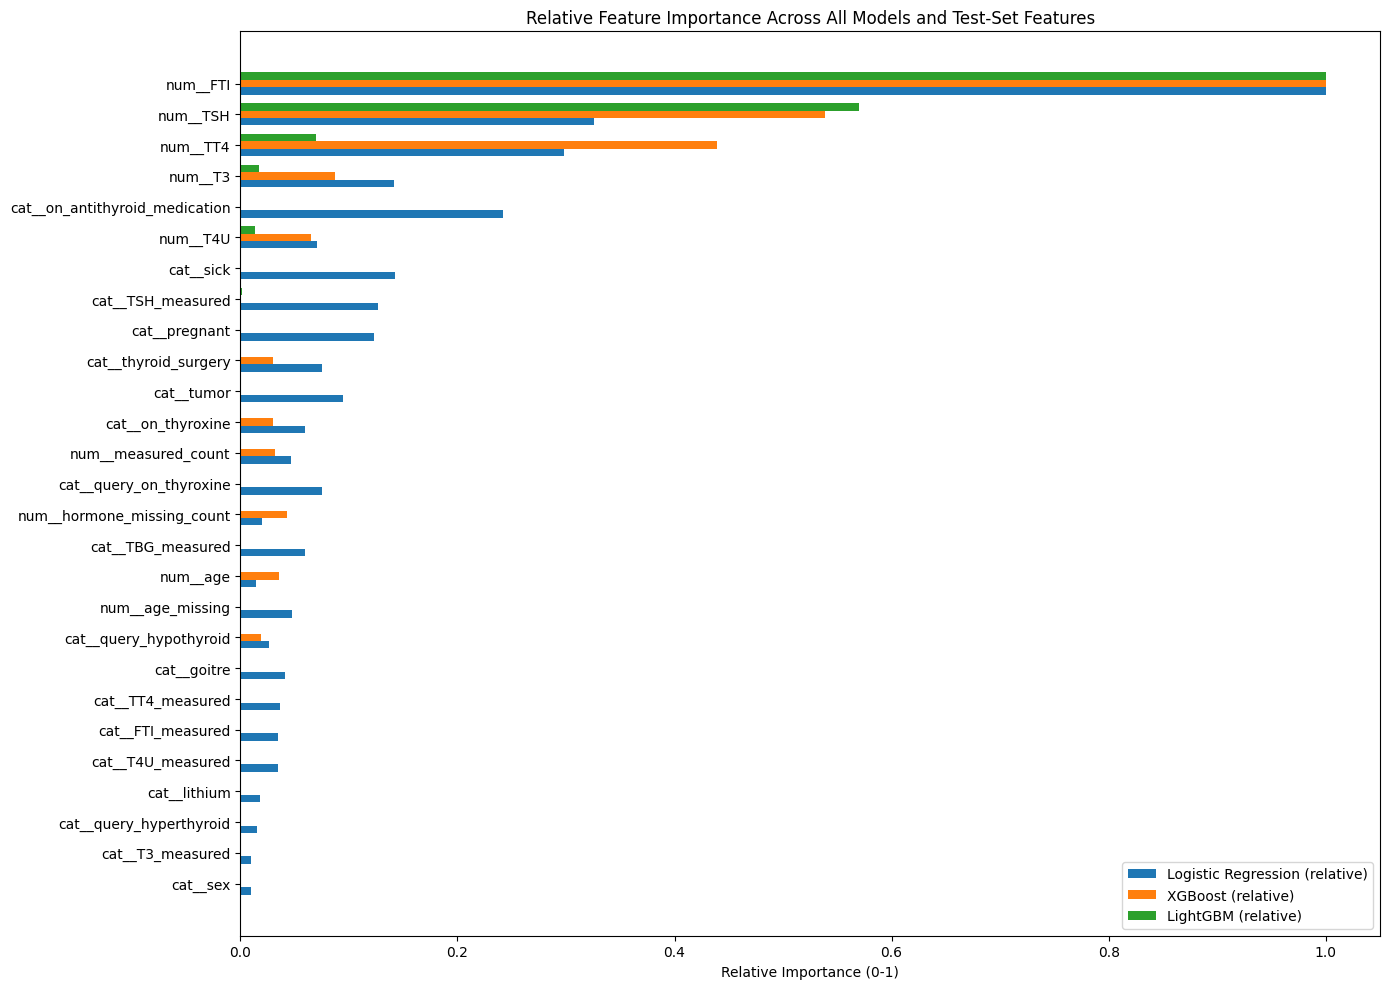

,Feature,Logistic Regression,XGBoost,LightGBM,Mean Importance
26,num__FTI,1.000000,1.000000,1.000000,1.000000
25,num__TSH,0.326201,0.538221,0.570085,0.478169
24,num__TT4,0.298116,0.438902,0.070103,0.269040
23,num__T3,0.141732,0.086827,0.016813,0.081791
22,cat__on_antithyroid_medication,0.242050,0.000000,0.000000,0.080683
21,num__T4U,0.070407,0.065207,0.013852,0.049822
20,cat__sick,0.142249,0.000000,0.000000,0.047416
19,cat__TSH_measured,0.126456,0.000000,0.001547,0.042668
18,cat__pregnant,0.122831,0.000000,0.000000,0.040944
17,cat__thyroid_surgery,0.074891,0.030253,0.000000,0.035048


In [90]:
# Creating a relative comparison of feature importance across all three models
features = list(feature_names_pp)

def _normalise(values):
    values = np.asarray(values, dtype=float)
    max_value = values.max() if values.size else 0.0
    return values / max_value if max_value > 0 else values

# Logistic Regression: use absolute standardised coefficients
log_imp = np.abs(logistic_model.named_steps["model"].coef_).ravel()

# XGBoost: gain-based importance aligned to transformed feature names
xgb_imp_dict = xgb_model.get_score(importance_type="gain")
xgb_keys = list(xgb_imp_dict.keys())

if xgb_keys and all(k.startswith("f") and k[1:].isdigit() for k in xgb_keys):
    xgb_imp = np.array([xgb_imp_dict.get(f"f{i}", 0.0) for i in range(len(features))], dtype=float)
else:
    xgb_imp = np.array([xgb_imp_dict.get(feature, 0.0) for feature in features], dtype=float)

# LightGBM: gain-based importance aligned to transformed feature names
lgb_names = list(lgb_model.feature_name())
lgb_gain = np.array(lgb_model.feature_importance(importance_type="gain"), dtype=float)
lgb_map = {name: value for name, value in zip(lgb_names, lgb_gain)}
lgb_imp = np.array([lgb_map.get(feature, 0.0) for feature in features], dtype=float)

assert len(log_imp) == len(features), "Logistic Regression importance length does not match transformed features."
assert len(xgb_imp) == len(features), "XGBoost importance length does not match transformed features."
assert len(lgb_imp) == len(features), "LightGBM importance length does not match transformed features."

log_norm = _normalise(log_imp)
xgb_norm = _normalise(xgb_imp)
lgb_norm = _normalise(lgb_imp)

importance_df = pd.DataFrame(
    {
        "Feature": features,
        "Logistic Regression": log_norm,
        "XGBoost": xgb_norm,
        "LightGBM": lgb_norm,
    }
)

importance_df["Mean Importance"] = importance_df[
    ["Logistic Regression", "XGBoost", "LightGBM"]
].mean(axis=1)

importance_df = importance_df.sort_values("Mean Importance", ascending=True).reset_index(drop=True)

plt.figure(figsize=(14, 10))
y = np.arange(len(importance_df))
bar_height = 0.24

plt.barh(
    y - bar_height,
    importance_df["Logistic Regression"],
    height=bar_height,
    label="Logistic Regression (relative)"
)
plt.barh(
    y,
    importance_df["XGBoost"],
    height=bar_height,
    label="XGBoost (relative)"
)
plt.barh(
    y + bar_height,
    importance_df["LightGBM"],
    height=bar_height,
    label="LightGBM (relative)"
)

plt.yticks(y, importance_df["Feature"])
plt.xlabel("Relative Importance (0-1)")
plt.title("Relative Feature Importance Across All Models and Test-Set Features")
plt.legend()
plt.tight_layout()
plt.show()

importance_df.sort_values("Mean Importance", ascending=False).head(10)


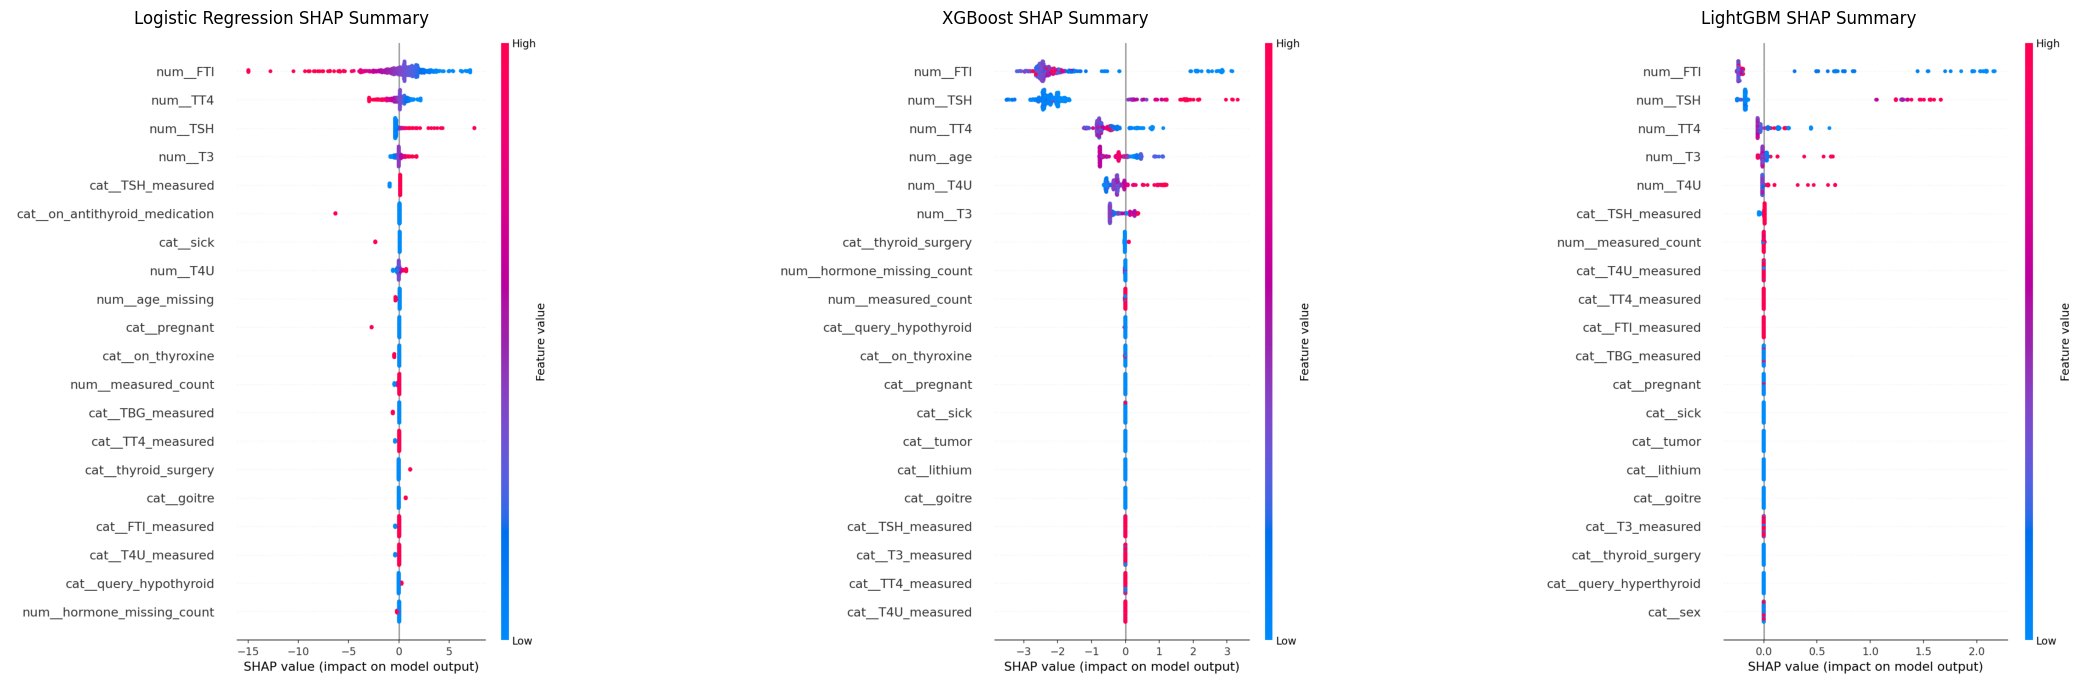

In [91]:
# SHAP summary plots for all three models using the transformed test-set features
X_shap = X_test_pp

def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

def _extract_shap_values(shap_output):
    values = shap_output.values if hasattr(shap_output, "values") else shap_output

    if isinstance(values, list):
        values = values[1] if len(values) > 1 else values[0]

    values = np.asarray(values)

    if values.ndim == 3:
        values = values[:, :, 1] if values.shape[-1] > 1 else values[:, :, 0]

    return values

X_shap_df = pd.DataFrame(_to_dense(X_shap), columns=feature_names_pp)

# Logistic Regression SHAP uses the scaled design matrix inside the pipeline
X_log_scaled = logistic_model.named_steps["scaler"].transform(X_shap)
X_log_df = pd.DataFrame(_to_dense(X_log_scaled), columns=feature_names_pp)

log_explainer = shap.LinearExplainer(logistic_model.named_steps["model"], X_log_df)
log_shap_values = _extract_shap_values(log_explainer(X_log_df))

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = _extract_shap_values(xgb_explainer(X_shap_df))

lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap_values = _extract_shap_values(lgb_explainer(X_shap_df))

# Save each SHAP plot as an image so dimensions stay consistent in the final panel
shap.summary_plot(log_shap_values, X_log_df, show=False)
plt.tight_layout()
plt.savefig("logreg_shap.png", bbox_inches="tight", dpi=150)
plt.close()

shap.summary_plot(xgb_shap_values, X_shap_df, show=False)
plt.tight_layout()
plt.savefig("xgb_shap.png", bbox_inches="tight", dpi=150)
plt.close()

shap.summary_plot(lgb_shap_values, X_shap_df, show=False)
plt.tight_layout()
plt.savefig("lgb_shap.png", bbox_inches="tight", dpi=150)
plt.close()

# Read back the saved images
img_log = plt.imread("logreg_shap.png")
img_xgb = plt.imread("xgb_shap.png")
img_lgb = plt.imread("lgb_shap.png")

# Display side by side
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

axes[0].imshow(img_log)
axes[0].axis("off")
axes[0].set_title("Logistic Regression SHAP Summary")

axes[1].imshow(img_xgb)
axes[1].axis("off")
axes[1].set_title("XGBoost SHAP Summary")

axes[2].imshow(img_lgb)
axes[2].axis("off")
axes[2].set_title("LightGBM SHAP Summary")

plt.tight_layout()
plt.show()


**Output analysis**

The importance comparison and SHAP summaries tell a consistent story.
**FTI** is the dominant feature across all three models, with **TSH** as the next strongest signal, while many categorical indicators contribute very little once the biochemical markers are present.

That pattern also improves trust in the final model because the dominant signals align with the thyroid-related variables that showed the clearest separation during EDA.


## 6. Present the Final Solution

### Selected model: XGBoost with threshold = 0.81.

Although all three models achieved zero FNs on validation after threshold optimisation, the test-set results showed the clearest separation in real-world utility. At the locked validation-chosen thresholds, XGBoost generalised best on test, with TP=20, FN=1, FP=1, TN=441, meaning it preserved a screening-first profile with minimal missed cases and the lowest false-positive burden among the candidates. This choice is further supported by the best calibration among the three models (lowest Brier = 0.009 and lowest ECE = 0.017), making its predicted probabilities, and therefore thresholding, more reliable across splits.


### Limitations and Risks

- Non-zero miss rate: even at the screening threshold (0.81), XGBoost produced false negatives on test, so it cannot be used as a standalone rule-out tool.
- Threshold fragility under shift: changes in prevalence, lab assays, reference ranges, or population mix can shift score distributions and degrade sensitivity/specificity.
- MNAR lab-ordering bias: the model may partly learn clinician ordering behaviour (tests ordered when suspicion is high), which may not generalise across sites/protocols.
- Limited interpretability: boosted trees are harder to justify case-by-case without explainability (e.g., SHAP), which can hinder clinical trust and governance.
- Uncertain estimates with few positives: performance metrics are sensitive to small changes in hypothyroid case counts, so reported recall/precision should be treated with uncertainty.


### Next steps

- Calibrate probabilities using Platt scaling or isotonic regression on a dedicated calibration set (or cross-validated calibration), then re-select the threshold    using a clinically defined rule (e.g., maximise recall subject to FP/day constraints).
- Cross-validated threshold selection (not a single validation split) to reduce “lucky” cutoffs.
- External / temporal validation across labs or time periods to quantify generalisation and drift.
- Add decision-curve analysis or cost-sensitive evaluation to formalise FN ≫ FP harms.
- Implement monitoring: prevalence shift, score distribution drift, and periodic threshold review.

<h2 style=" color:#08306b;">8.0 References</h2>

Austin, P.C., White, I.R., Lee, D.S. and van Buuren, S. (2020). 'Missing data in clinical research: A tutorial on multiple imputation',
<i>Canadian Journal of Cardiology</i>, 37(9). doi: https://doi.org/10.1016/j.cjca.2020.11.010.

‌Kang, H. (2013). 'The prevention and dandling of the missing data', <i>Korean Journal of Anesthesiology</i>, 64(5), pp.402–406. doi: https://doi.org/10.4097/kjae.2013.64.5.402. 

Quinlan, R. (1986). 'Thyroid Disease'. Available at: https://doi.org/10.24432/C5D010 (Accessed: 31 October 2025).

